# 0. Imports

In [1]:
import pandas as pd
import os 
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

In [2]:
print(os.getcwd())
os.chdir("../")
os.getcwd()

c:\Users\leoco\Documents\cours\M2_MOSEF\ML_theory\land_value_prediction\notebooks


'c:\\Users\\leoco\\Documents\\cours\\M2_MOSEF\\ML_theory\\land_value_prediction'

In [3]:
import src.land_value_prediction.analyse_base_de_donnees.analyse_variable_quantitative as avqt 
from src.land_value_prediction.pipeline_traitement import (delete_useless_columns, 
                                                           do_feature_engineering, 
                                                           fill_missing_surface_terrain, 
                                                           cast_variables, 
                                                           one_hot_encode_type_local, 
                                                           impute_commune_features_by_neighbors)

In [4]:
train = pd.read_parquet("data/processed/train_test_out_sample_split/idf_vf_train.parquet")
train.head()

,date_mutation,nature_mutation,valeur_fonciere,adresse_numero,adresse_nom_voie,adresse_code_voie,code_postal,code_commune,nom_commune,code_departement,...,nb_restauration_2000m,nb_sante_2000m,nb_loisirs_2000m,nb_services_2000m,nb_transport_lourd_2000m,nb_bus_2000m,nb_transport_autre_2000m,nb_total_2000m,diversite_2000m,densite_rel_2000m
0,2021-02-18,Vente,453000.0,149.0,AV PARMENTIER,7067,75010.0,75110,Paris 10e Arrondissement,75,...,65,12,311,14,52,363,29,1074,9,2.005092
1,2021-06-16,Vente,210000.0,12.0,AV LOUIS PASTEUR,5180,92220.0,92007,Bagneux,92,...,9,2,332,8,5,278,0,734,8,0.919889
2,2022-07-11,Vente,640000.0,60.0,RUE MONGE,6432,75005.0,75105,Paris 5e Arrondissement,75,...,89,17,270,18,51,453,43,1186,9,2.168607
3,2021-03-26,Vente,1530000.0,22.0,QUAI DES CELESTINS,1636,75004.0,75104,Paris 4e Arrondissement,75,...,90,12,252,17,55,434,49,1128,9,2.177448
4,2022-12-05,Vente,325000.0,80.0,RUE DE TOURAINE,3040,77550.0,77296,Moissy-Cramayel,77,...,10,3,41,7,1,72,1,141,9,-1.035969


Supprimons les colonnes servant à construire la base mais non utiles pour la modélisation.  

In [5]:
columns_to_drop_for_analysis = [
                                #valeur_fonciere, à garder pour d'éventuels analyses
                                #surface_reelle_bati, à garder pour d'éventuels analyses
                                "nature_mutation", 
                                # une grande partie des variables de localisation sont redondantes avec le prix des maisons voisines 
                                # qui est un target encoding de la zone géographique + les POIs: 
                                "adresse_nom_voie",
                                "adresse_numero", 
                                "adresse_code_voie", 
                                "code_postal",      
                                # "code_departement", # utile pour séparer en plusieurs modèles géographiques
                                "id_parcelle",      
                                # "code_type_local", sera supprimé dans le typing des variables : redondant avec type_local
                                "code_cadastral",     
                                "annee",
                                "semestre", 
                                "semestre_precedent", 
                                "annee_precedente", 
                                "trimestre_precedent", 
                                "commune_revenu_score_2013_commune", # redondant avec commune_revenu_median_2020
                                "prix_m2_moyen_maisons_voisines", # on préferera prix_m2_median_maisons_voisines
                                ]

print(f"Shape initiale: {train.shape}")
train = delete_useless_columns(train, columns_to_drop_for_analysis)
print(f"Shape après suppression des colonnes inutiles: {train.shape}")

Shape initiale: (469174, 118)
Shape après suppression des colonnes inutiles: (469174, 104)


# 1. Un peu de feature engineering

In [6]:
train = do_feature_engineering(train)
train.head()

,date_mutation,valeur_fonciere,code_commune,nom_commune,code_departement,nombre_lots,type_local,surface_reelle_bati,nombre_pieces_principales,surface_terrain,...,log_surface_terrain,densite_lots,nb_jours_depuis_janvier_2021,distance_paris,nord_paris,est_paris,sud_paris,ouest_paris,prix_median_x_distance,surface_x_type
0,2021-02-18,453000.0,75110,Paris 10e Arrondissement,75,1,Appartement,48.0,3.0,NaN,...,NaN,0.693147,48,0.022898,1,1,0,0,251.875813,96.0
1,2021-06-16,210000.0,92007,Bagneux,92,2,Appartement,45.0,3.0,NaN,...,NaN,1.098612,166,0.067297,0,0,1,1,400.319181,90.0
2,2022-07-11,640000.0,75105,Paris 5e Arrondissement,75,2,Appartement,51.0,2.0,NaN,...,NaN,1.098612,556,0.012333,0,0,1,1,159.726926,102.0
3,2021-03-26,1530000.0,75104,Paris 4e Arrondissement,75,1,Appartement,120.0,3.0,NaN,...,NaN,0.693147,84,0.010092,0,1,1,0,130.780745,240.0
4,2022-12-05,325000.0,77296,Moissy-Cramayel,77,0,Maison,88.0,5.0,196.0,...,5.283204,0.000000,703,0.337793,0,1,1,0,1062.413436,88.0


# 2. Typage des variables 

In [7]:
train.sample(5)

,date_mutation,valeur_fonciere,code_commune,nom_commune,code_departement,nombre_lots,type_local,surface_reelle_bati,nombre_pieces_principales,surface_terrain,...,log_surface_terrain,densite_lots,nb_jours_depuis_janvier_2021,distance_paris,nord_paris,est_paris,sud_paris,ouest_paris,prix_median_x_distance,surface_x_type
319751,2024-06-28,225000.0,93010,Bondy,93,1,Appartement,80.0,4.0,NaN,...,NaN,0.693147,1274,0.128400,1,1,0,0,424.709014,160.0
422570,2021-12-16,176000.0,78208,Élancourt,78,1,Appartement,78.0,4.0,NaN,...,NaN,0.693147,349,0.405517,0,0,1,1,1097.499216,156.0
424951,2023-10-16,213565.0,78621,Trappes,78,1,Appartement,79.0,4.0,NaN,...,NaN,0.693147,1018,0.372655,0,0,1,1,976.628959,158.0
11357,2022-11-29,950625.0,94042,Joinville-le-Pont,94,1,Appartement,140.0,3.0,NaN,...,NaN,0.693147,697,0.126055,0,1,1,0,812.571430,280.0
403291,2021-10-29,292000.0,77468,Torcy,77,1,Appartement,80.0,4.0,NaN,...,NaN,0.693147,301,0.297244,0,1,1,0,866.858414,160.0


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 469174 entries, 0 to 469173
Columns: 115 entries, date_mutation to surface_x_type
dtypes: datetime64[ns](1), float32(16), float64(48), int64(44), object(6)
memory usage: 383.0+ MB


In [9]:
train = cast_variables(train)
train

La colonne code_commune a trop de modalités (1283) pour être castée en 'category'.
La colonne nom_commune a trop de modalités (1279) pour être castée en 'category'.


,date_mutation,valeur_fonciere,code_commune,nom_commune,code_departement,nombre_lots,type_local,surface_reelle_bati,nombre_pieces_principales,surface_terrain,...,log_surface_terrain,densite_lots,nb_jours_depuis_janvier_2021,distance_paris,nord_paris,est_paris,sud_paris,ouest_paris,prix_median_x_distance,surface_x_type
0,2021-02-18,453000.0,75110,Paris 10e Arrondissement,75,1,Appartement,48,3,NaN,...,NaN,0.693147,48,0.022898,1,1,0,0,251.875809,96
1,2021-06-16,210000.0,92007,Bagneux,92,2,Appartement,45,3,NaN,...,NaN,1.098612,166,0.067297,0,0,1,1,400.319183,90
2,2022-07-11,640000.0,75105,Paris 5e Arrondissement,75,2,Appartement,51,2,NaN,...,NaN,1.098612,556,0.012333,0,0,1,1,159.726929,102
3,2021-03-26,1530000.0,75104,Paris 4e Arrondissement,75,1,Appartement,120,3,NaN,...,NaN,0.693147,84,0.010092,0,1,1,0,130.780746,240
4,2022-12-05,325000.0,77296,Moissy-Cramayel,77,0,Maison,88,5,196.0,...,5.283204,0.000000,703,0.337793,0,1,1,0,1062.413452,88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469169,2022-08-24,110000.0,77014,Avon,77,2,Appartement,70,4,NaN,...,NaN,1.098612,600,0.586708,0,1,1,0,1287.721924,140
469170,2021-09-03,334700.0,78168,Coignières,78,0,Maison,103,5,474.0,...,6.163315,0.000000,245,0.445244,0,0,1,1,1504.184082,103
469171,2022-05-06,215000.0,77261,Lorrez-le-Bocage-Préaux,77,0,Maison,110,4,850.0,...,6.746412,0.000000,490,0.827513,0,1,1,0,1617.224731,110
469172,2021-06-09,333000.0,78029,Aubergenville,78,0,Maison,85,5,244.0,...,5.501258,0.000000,159,0.512374,1,0,0,1,1725.429565,85


Mémoire allouée à la table largement diminué : 

In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 469174 entries, 0 to 469173
Columns: 115 entries, date_mutation to surface_x_type
dtypes: category(7), datetime64[ns](1), float32(62), object(2), uint16(11), uint8(32)
memory usage: 149.0+ MB


# 3.1 Analyse des variables numériques  

In [11]:
numerical_dvf_features = ['valeur_fonciere',
                          'nombre_lots',
                          'surface_reelle_bati',
                          'nombre_pieces_principales',
                          'surface_terrain',
                          'prix_m2',
                          'surface_par_piece',
                          'ratio_terrain_bati',
                          'log_surface_terrain',
                          'densite_lots',
                          'nb_jours_depuis_janvier_2021',
                          'distance_paris',
                          'prix_median_x_distance',
                          'surface_x_type']

numerical_communes_features = ['prix_m2_median_maisons_voisines',
                               'ecart_prix_median_pct',
                               'commune_revenu_median_2020',
                               'commune_etablissements_agriculture_2021',
                               'commune_etablissements_industrie_2021',
                               'commune_etablissements_construction_2021',
                               'commune_etablissements_1_salarie_2021',
                               'commune_etablissements_10_plus_salaries_2021',
                               'commune_densite_population_active_2020',
                               'commune_taux_residences_secondaires',
                               'commune_taux_logements_vacants',
                               'commune_taux_proprietaires',
                               'commune_ratio_residences_secondaires_population',
                               'commune_densite_residences_principales_2020',
                               'commune_taux_chomage_15_64',
                               'commune_taux_emploi',
                               'commune_evolution_emploi_2014_2020',
                               'commune_part_services_entreprises',
                               'commune_part_commerce_tourisme',
                               'commune_part_admin_sante',
                               'commune_nb_etablissements_par_menage',
                               'commune_taux_etablissements_10_plus',
                               'commune_sante_score_2013_commune',
                               'commune_education_score_2013_commune',
                               'commune_idh2_2013_commune',
                               'commune_taux_criminalite_moyen',
                               'commune_taux_croissance_pop',
                               'commune_densite_pop']

numerical_macro_features = ['Taux_moyen_credit_immo_lag1t',
                            'Taux_moyen_credit_immo_lag2t',
                            'Taux_moyen_credit_immo_lag3t',
                            'Taux_moyen_credit_immo_lag4t',
                            'Evolution_PIB_volume_en_%_base2020_lag1t',
                            'Evolution_PIB_volume_en_%_base2020_lag2t',
                            'Evolution_PIB_volume_en_%_base2020_lag3t',
                            'Evolution_PIB_volume_en_%_base2020_lag4t',
                            'Indice_confiance_menage_lag1m',
                            'Indice_confiance_menage_lag2m',
                            'Indice_confiance_menage_lag3m',
                            'Indice_confiance_menage_lag6m',
                            'IPC_base_2015_lag1m',
                            'IPC_base_2015_lag3m',
                            'IPC_base_2015_lag6m',
                            'IPC_base_2015_lag12m']

numerical_poi_features = ['nb_education_500m',
                          'dist_education',
                          'nb_commerce_500m',
                          'dist_commerce',
                          'nb_restauration_500m',
                          'dist_restauration',
                          'nb_sante_500m',
                          'dist_sante',
                          'nb_loisirs_500m',
                          'dist_loisirs',
                          'nb_services_500m',
                          'dist_services',
                          'nb_transport_lourd_500m',
                          'dist_transport_lourd',
                          'nb_bus_500m',
                          'dist_bus',
                          'nb_transport_autre_500m',
                          'dist_transport_autre',
                          'nb_total_500m',
                          'diversite_500m',
                          'densite_rel_500m',
                          'nb_education_1000m',
                          'nb_commerce_1000m',
                          'nb_restauration_1000m',
                          'nb_sante_1000m',
                          'nb_loisirs_1000m',
                          'nb_services_1000m',
                          'nb_transport_lourd_1000m',
                          'nb_bus_1000m',
                          'nb_transport_autre_1000m',
                          'nb_total_1000m',
                          'diversite_1000m',
                          'densite_rel_1000m',
                          'nb_education_2000m',
                          'nb_commerce_2000m',
                          'nb_restauration_2000m',
                          'nb_sante_2000m',
                          'nb_loisirs_2000m',
                          'nb_services_2000m',
                          'nb_transport_lourd_2000m',
                          'nb_bus_2000m',
                          'nb_transport_autre_2000m',
                          'nb_total_2000m',
                          'diversite_2000m',
                          'densite_rel_2000m',
]

#### Statistiques descriptives 

In [12]:
train[numerical_dvf_features + numerical_communes_features].describe()

,valeur_fonciere,nombre_lots,surface_reelle_bati,nombre_pieces_principales,surface_terrain,prix_m2,surface_par_piece,ratio_terrain_bati,log_surface_terrain,densite_lots,...,commune_part_commerce_tourisme,commune_part_admin_sante,commune_nb_etablissements_par_menage,commune_taux_etablissements_10_plus,commune_sante_score_2013_commune,commune_education_score_2013_commune,commune_idh2_2013_commune,commune_taux_criminalite_moyen,commune_taux_croissance_pop,commune_densite_pop
count,4.691740e+05,469174.000000,469174.000000,469174.000000,150398.000000,469174.000000,469174.000000,469174.000000,150398.000000,469174.000000,...,469174.000000,469174.000000,469174.000000,469174.000000,469172.000000,469174.000000,469120.000000,469174.000000,469174.000000,469174.000000
mean,3.845284e+05,1.092838,71.640575,3.227148,528.036255,5843.766113,22.323397,1.888682,5.894701,0.629256,...,0.712082,0.106351,0.090260,0.175241,0.646531,0.609123,0.600901,0.566523,0.445147,9701.573242
std,3.113569e+05,0.961958,42.115310,1.537796,1283.502563,3199.308105,6.696558,9.934069,0.801101,0.478216,...,0.113812,0.042330,0.091197,0.057670,0.086920,0.196926,0.136523,0.493488,1.184763,10207.645508
min,1.500000e+04,0.000000,10.000000,1.000000,1.000000,1500.000000,1.000000,0.000000,0.693147,0.000000,...,0.000000,0.000000,0.011123,0.000000,0.000000,0.113469,0.236949,0.000000,-9.889071,3.171247
25%,2.000000e+05,0.000000,43.000000,2.000000,240.000000,3314.446899,18.400000,0.000000,5.484797,0.000000,...,0.643678,0.081081,0.058081,0.139573,0.593166,0.460013,0.507020,0.365142,-0.301123,2044.734863
50%,3.000000e+05,1.000000,65.000000,3.000000,400.000000,4769.230957,21.250000,0.000000,5.993961,0.693147,...,0.716944,0.099314,0.071929,0.168591,0.648913,0.588408,0.591576,0.457016,0.276076,5692.875488
75%,4.550000e+05,2.000000,90.000000,4.000000,540.000000,8007.162231,25.000000,2.383562,6.293419,1.098612,...,0.801589,0.122034,0.094764,0.206643,0.706225,0.775818,0.711022,0.619372,0.916762,13795.924805
max,8.150000e+06,23.000000,880.000000,15.000000,181873.000000,15000.000000,375.000000,2273.412598,12.111070,3.178054,...,1.000000,1.000000,1.299053,0.555556,1.000000,1.000000,0.904551,12.795809,15.865758,39957.222656


#### Cartes de visualisation des prix 

In [13]:
# Filtrer les données avec des coordonnées valides
train_map = train.dropna(subset=['longitude', 'latitude', 'prix_m2']).sample(frac=0.1, random_state=42)  # Échantillonner pour performance

# Créer la carte interactive avec plotly et une échelle de couleur plus progressive
fig = px.density_map(
    train_map, 
    lat='latitude', 
    lon='longitude', 
    z='prix_m2',
    radius=8,
    center=dict(lat=48.8566, lon=2.3522),
    zoom=8.5,
    # color_continuous_scale='Viridis',  
    range_color=[train_map['prix_m2'].quantile(0.05), train_map['prix_m2'].quantile(0.95)],  # Meilleure répartition
    labels={'prix_m2': 'Prix au m² (€)'},
    title='Carte interactive des prix au m² en Île-de-France',
    height=700
)

fig.update_traces(opacity=0.6)

fig.update_layout(
    mapbox_style="open-street-map",
    font=dict(size=12),
    title_font=dict(size=16, family='Arial Black'),
    coloraxis_colorbar=dict(title="Prix au m² (€)")
)

fig.show()

In [14]:
# Calculer le prix médian par commune
prix_par_commune = train.groupby(["code_commune", "nom_commune"]).agg({
    'prix_m2': 'median',
    'latitude': 'first',
    'longitude': 'first'
}).reset_index()

# Supprimer les valeurs manquantes
prix_par_commune = prix_par_commune.dropna(subset=['longitude', 'latitude', 'prix_m2'])

# Créer la carte avec agrégation par commune
# Créer des bins de 250 euros pour une échelle de couleur progressive
prix_min = prix_par_commune['prix_m2'].quantile(0.05)
prix_max = prix_par_commune['prix_m2'].quantile(0.95)
n_bins = int((prix_max - prix_min) / 250)

fig = px.scatter_map(
    prix_par_commune,
    lat='latitude',
    lon='longitude',
    color='prix_m2',
    size='prix_m2',
    hover_name='nom_commune',
    hover_data={'prix_m2': ':.0f', 'latitude': False, 'longitude': False},
    color_continuous_scale='Turbo',
    range_color=[prix_min, prix_max],
    color_continuous_midpoint=(prix_min + prix_max) / 2,
    size_max=20,
    zoom=8.5,
    center=dict(lat=48.8566, lon=2.3522),
    title='Prix médian au m² par commune en Île-de-France',
    labels={'prix_m2': 'Prix médian au m² (€)'},
    height=700
)

fig.update_layout(
    mapbox_style="open-street-map",
    font=dict(size=12),
    title_font=dict(size=16, family='Arial Black'),
    coloraxis_colorbar=dict(title="Prix médian au m² (€)")
)

fig.show()

#### Valeurs manquantes 

In [15]:
train.isnull().sum()

date_mutation             0
valeur_fonciere           0
code_commune              0
nom_commune               0
code_departement          0
                         ..
est_paris                 0
sud_paris                 0
ouest_paris               0
prix_median_x_distance    0
surface_x_type            0
Length: 115, dtype: int64

##### 1) Surface terrain 

In [16]:
train[train['surface_terrain'].isnull()]["code_commune"].value_counts(normalize=True).round(2) * 100

code_commune
75115    3.0
75118    3.0
75117    3.0
75111    2.0
75116    2.0
        ... 
78320    0.0
77032    0.0
91079    0.0
78451    0.0
78010    0.0
Name: proportion, Length: 966, dtype: float64

In [17]:
train[train['surface_terrain'] == 0].shape

(0, 115)

In [18]:
train["type_local"].value_counts(normalize=True).round(2) * 100

type_local
Appartement    67.0
Maison         33.0
Name: proportion, dtype: float64

In [19]:
train[train['surface_terrain'].isnull()]["type_local"].value_counts(normalize=True).round(2) * 100

type_local
Appartement    96.0
Maison          4.0
Name: proportion, dtype: float64

Si la surface terrain est manquante cela veut sûrement dire que le bien immobilier n'est pas associé à un terrain (ex: Paris intra muros).  On voit que ce sont très souvent des appartements. On va mettre à zéro les surfaces de terrain:

In [20]:
train = fill_missing_surface_terrain(train)
train

,date_mutation,valeur_fonciere,code_commune,nom_commune,code_departement,nombre_lots,type_local,surface_reelle_bati,nombre_pieces_principales,surface_terrain,...,log_surface_terrain,densite_lots,nb_jours_depuis_janvier_2021,distance_paris,nord_paris,est_paris,sud_paris,ouest_paris,prix_median_x_distance,surface_x_type
0,2021-02-18,453000.0,75110,Paris 10e Arrondissement,75,1,Appartement,48,3,0.0,...,0.000000,0.693147,48,0.022898,1,1,0,0,251.875809,96
1,2021-06-16,210000.0,92007,Bagneux,92,2,Appartement,45,3,0.0,...,0.000000,1.098612,166,0.067297,0,0,1,1,400.319183,90
2,2022-07-11,640000.0,75105,Paris 5e Arrondissement,75,2,Appartement,51,2,0.0,...,0.000000,1.098612,556,0.012333,0,0,1,1,159.726929,102
3,2021-03-26,1530000.0,75104,Paris 4e Arrondissement,75,1,Appartement,120,3,0.0,...,0.000000,0.693147,84,0.010092,0,1,1,0,130.780746,240
4,2022-12-05,325000.0,77296,Moissy-Cramayel,77,0,Maison,88,5,196.0,...,5.283204,0.000000,703,0.337793,0,1,1,0,1062.413452,88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469169,2022-08-24,110000.0,77014,Avon,77,2,Appartement,70,4,0.0,...,0.000000,1.098612,600,0.586708,0,1,1,0,1287.721924,140
469170,2021-09-03,334700.0,78168,Coignières,78,0,Maison,103,5,474.0,...,6.163315,0.000000,245,0.445244,0,0,1,1,1504.184082,103
469171,2022-05-06,215000.0,77261,Lorrez-le-Bocage-Préaux,77,0,Maison,110,4,850.0,...,6.746412,0.000000,490,0.827513,0,1,1,0,1617.224731,110
469172,2021-06-09,333000.0,78029,Aubergenville,78,0,Maison,85,5,244.0,...,5.501258,0.000000,159,0.512374,1,0,0,1,1725.429565,85


In [21]:
train[train['latitude'].isnull()]

,date_mutation,valeur_fonciere,code_commune,nom_commune,code_departement,nombre_lots,type_local,surface_reelle_bati,nombre_pieces_principales,surface_terrain,...,log_surface_terrain,densite_lots,nb_jours_depuis_janvier_2021,distance_paris,nord_paris,est_paris,sud_paris,ouest_paris,prix_median_x_distance,surface_x_type


##### 2) Commune revenu médian, commune_sante_score_2013_commune et commune_idh2_2013_commune

In [22]:
train[train["commune_revenu_median_2020"].isnull()][ "commune_densite_pop"].describe()

count    45.000000
mean     16.427782
std       8.511133
min       3.171247
25%      10.154526
50%      17.073172
75%      22.302158
max      31.355932
Name: commune_densite_pop, dtype: float64

Ce sont des villages (peu d'habitants au mètre carré) pour lesquels les données de revenu médian ne sont pas disponibles.

In [23]:
train[train["commune_idh2_2013_commune"].isnull()]["nom_commune"].value_counts()

nom_commune
Chatignonville          6
Mulcent                 6
Menouville              5
Passy-sur-Seine         4
Obsonville              4
Roinvilliers            3
Bois-Herpin             3
Garentreville           3
Montenils               3
Vulaines-lès-Provins    3
Le Plessis-Gassot       3
Gambaiseuil             2
Vaudherland             2
Épinay-Champlâtreux     2
Sigy                    2
Le Tartre-Gaudran       2
Châtenay-en-France      1
Name: count, dtype: int64

In [24]:
train[train["commune_sante_score_2013_commune"].isnull()]["nom_commune"].value_counts()

nom_commune
Le Tartre-Gaudran    2
Name: count, dtype: int64

On va recouper les valeurs manquantes de ces indicateurs communaux avec les valeurs des villages voisins:

In [25]:
train = impute_commune_features_by_neighbors(
    train,
    features_to_impute=['commune_revenu_median_2020', 'commune_sante_score_2013_commune', 'commune_idh2_2013_commune'], 
    radius_km=10
)

print("Nombre de valeurs manquantes après imputation :", train.isnull().sum().sum())

Commune: Roinvilliers | Variable: commune_idh2_2013_commune | #voisins: 664 | Imputed value: 0.6625069379806519
Commune: Montenils | Variable: commune_revenu_median_2020 | #voisins: 92 | Imputed value: 28060.0
Commune: Montenils | Variable: commune_idh2_2013_commune | #voisins: 92 | Imputed value: 0.6625068783760071
Commune: Garentreville | Variable: commune_idh2_2013_commune | #voisins: 496 | Imputed value: 0.6625069379806519
Commune: Garentreville | Variable: commune_idh2_2013_commune | #voisins: 417 | Imputed value: 0.6625069379806519
Commune: Obsonville | Variable: commune_idh2_2013_commune | #voisins: 290 | Imputed value: 0.6625068783760071
Commune: Vaudherland | Variable: commune_idh2_2013_commune | #voisins: 18583 | Imputed value: 0.6625069379806519
Commune: Gambaiseuil | Variable: commune_revenu_median_2020 | #voisins: 1957 | Imputed value: 28060.0
Commune: Gambaiseuil | Variable: commune_idh2_2013_commune | #voisins: 1957 | Imputed value: 0.6625069379806519
Commune: Obsonville

#### Analyse des distributions 

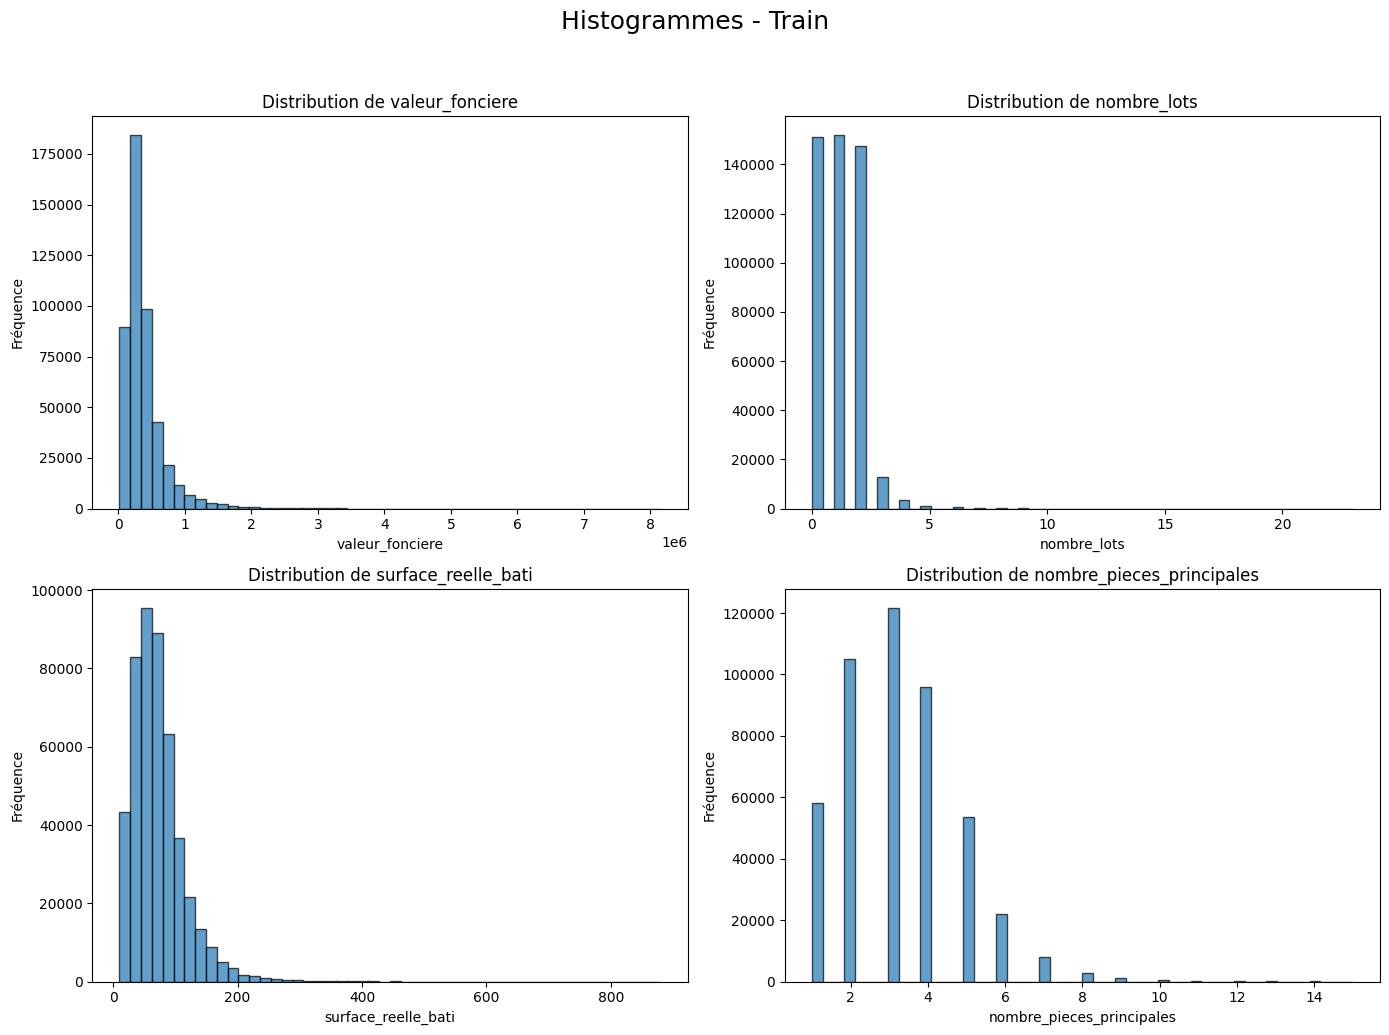

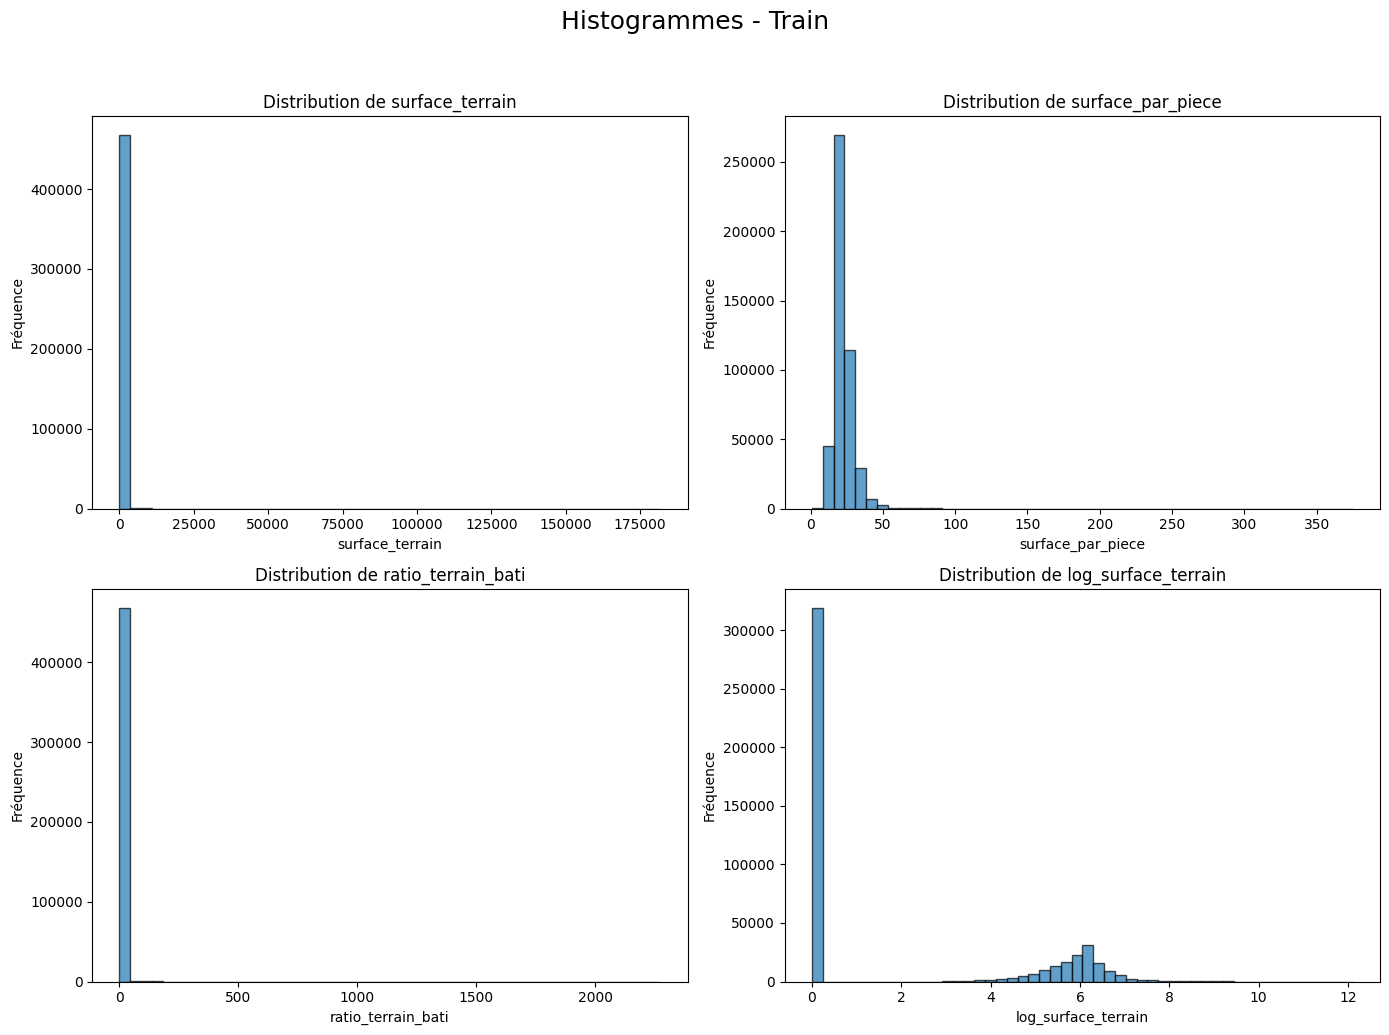

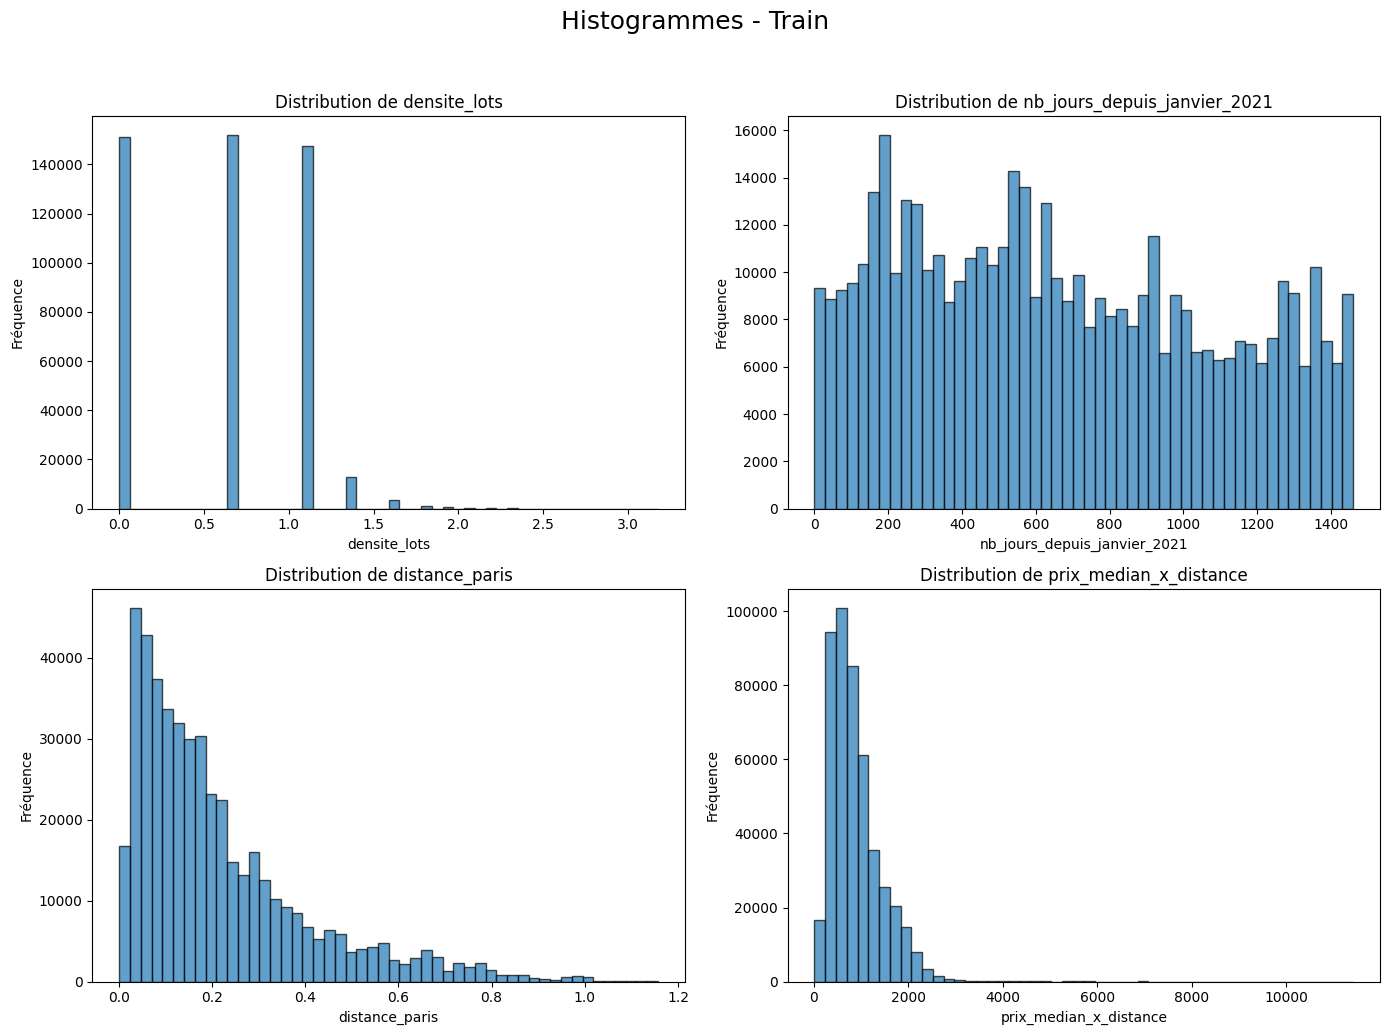

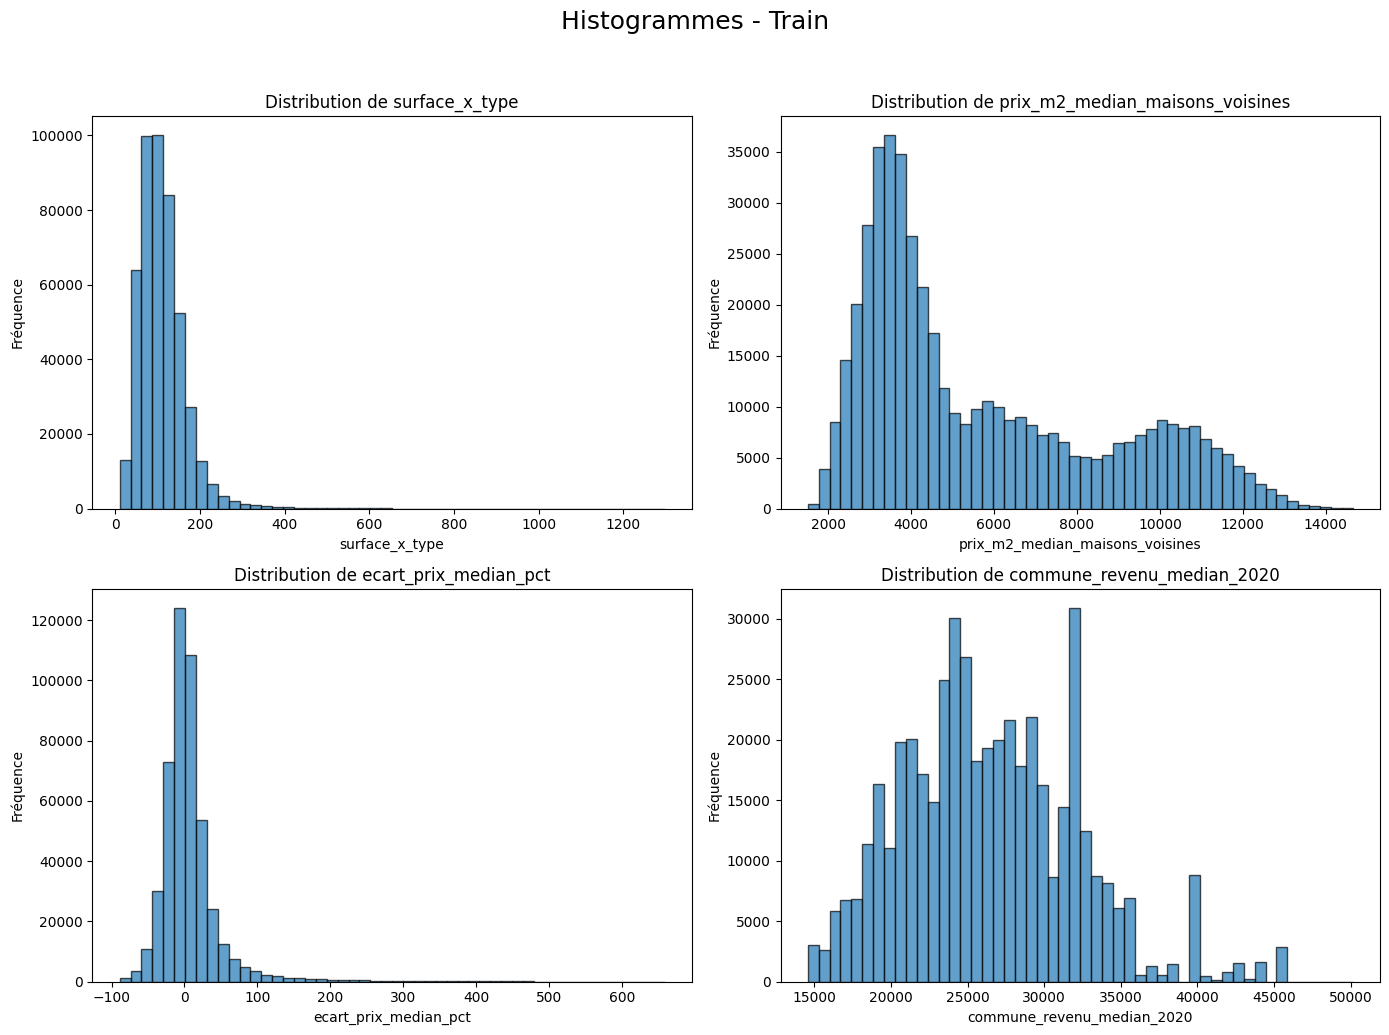

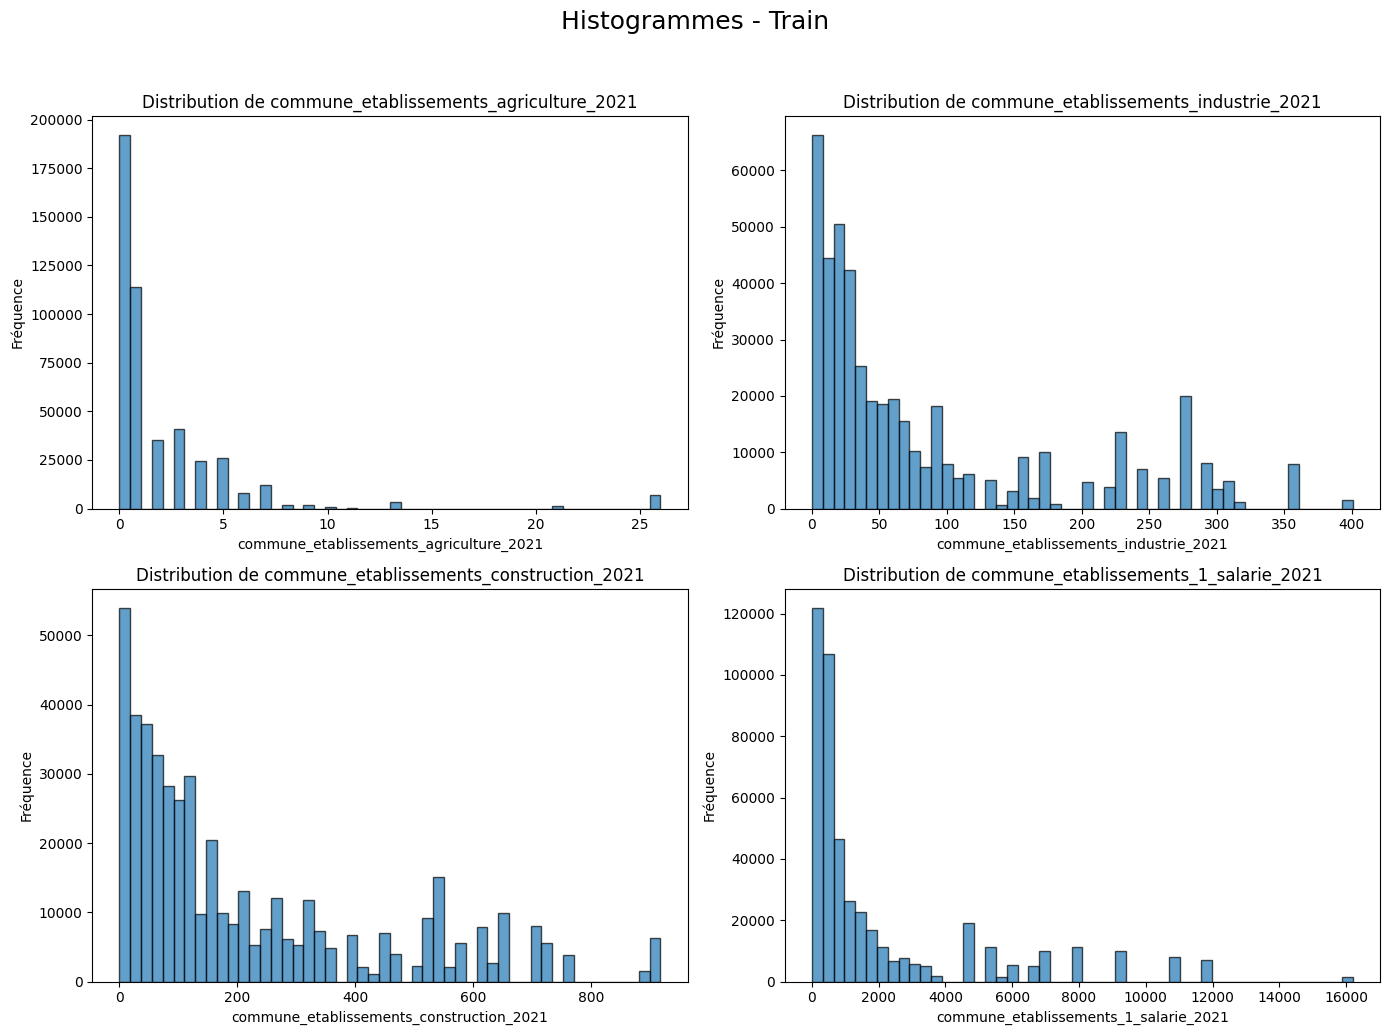

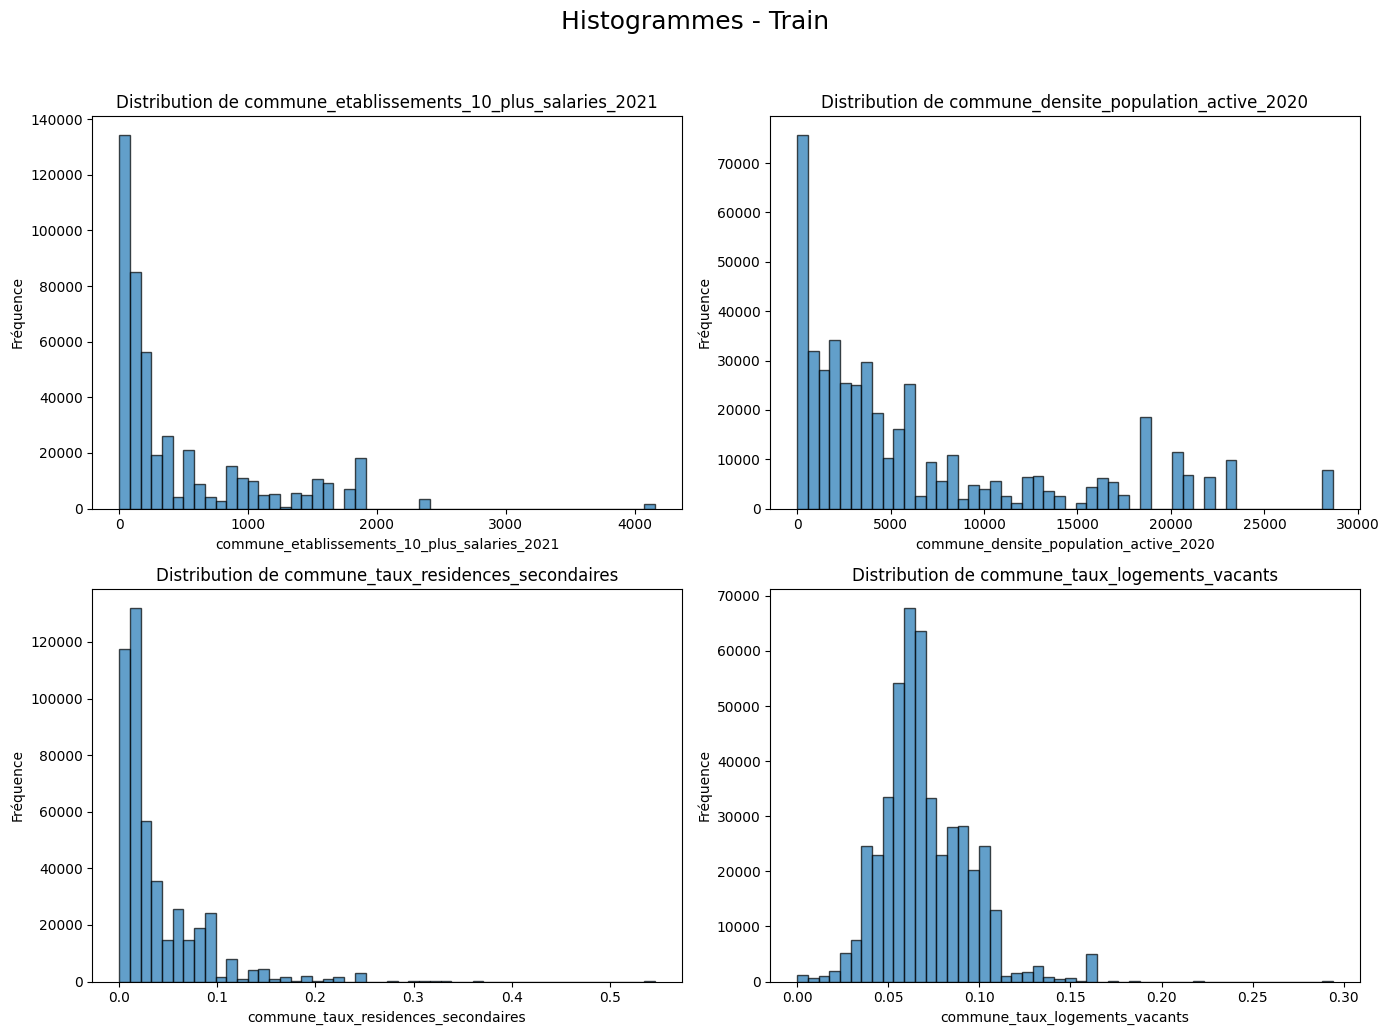

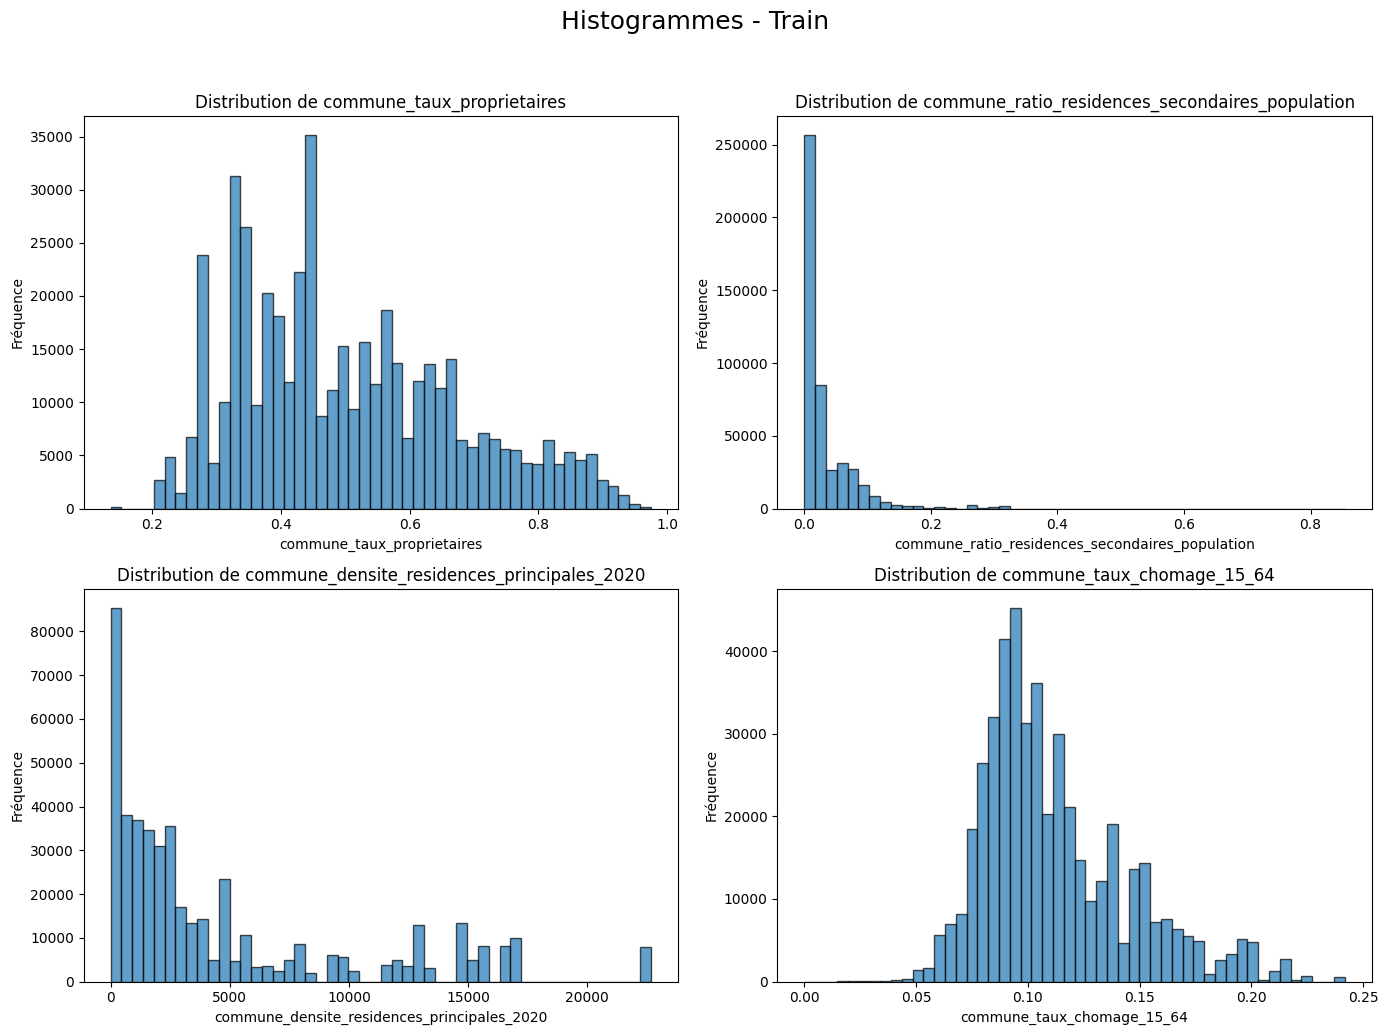

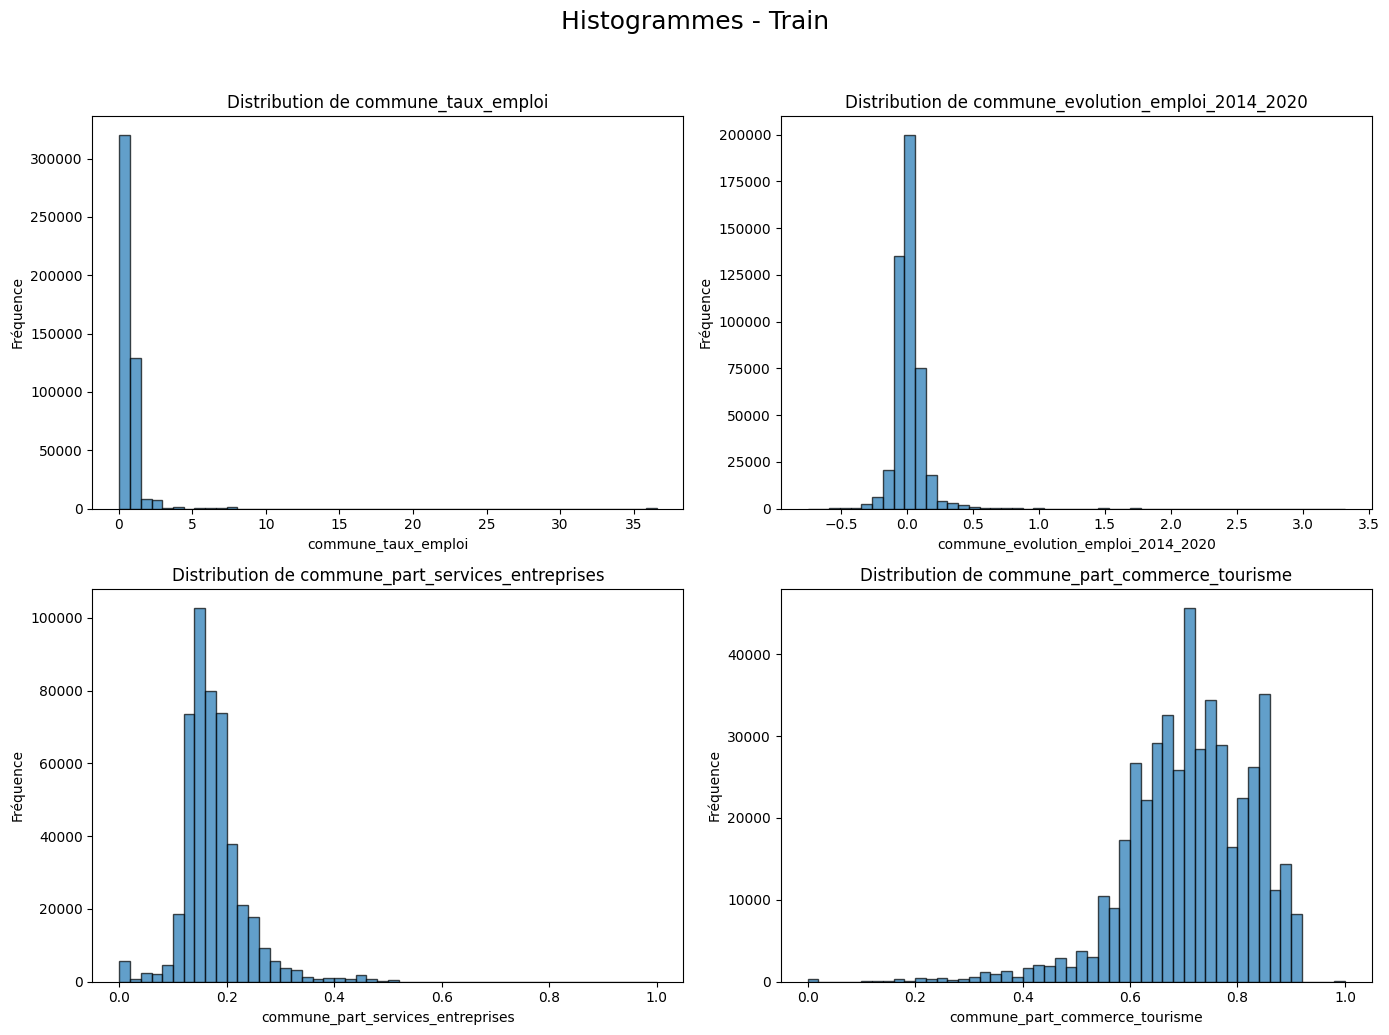

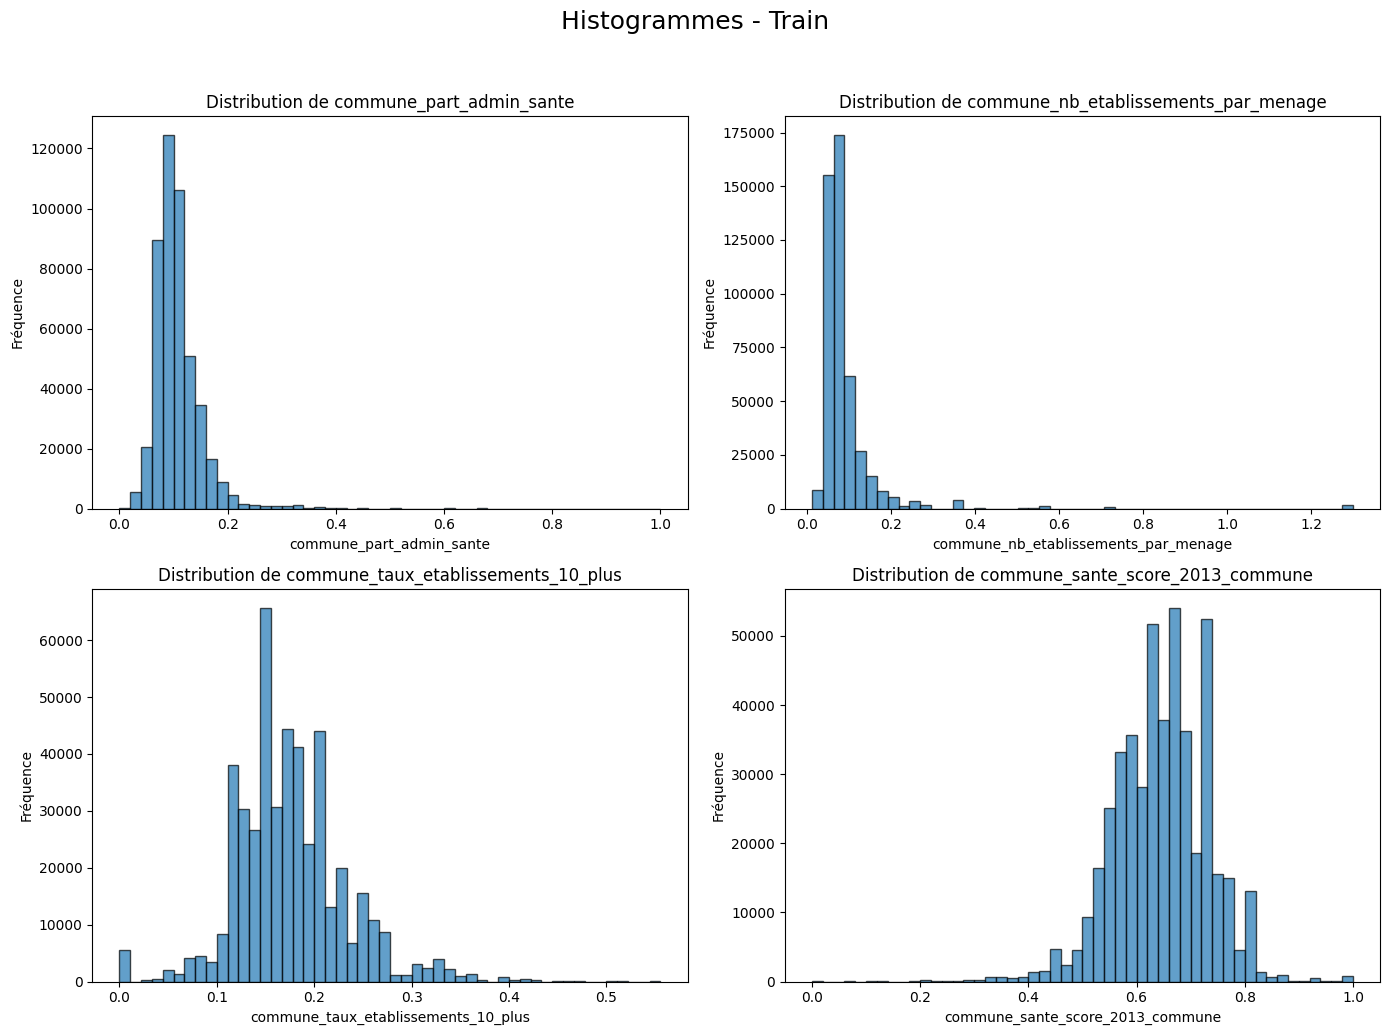

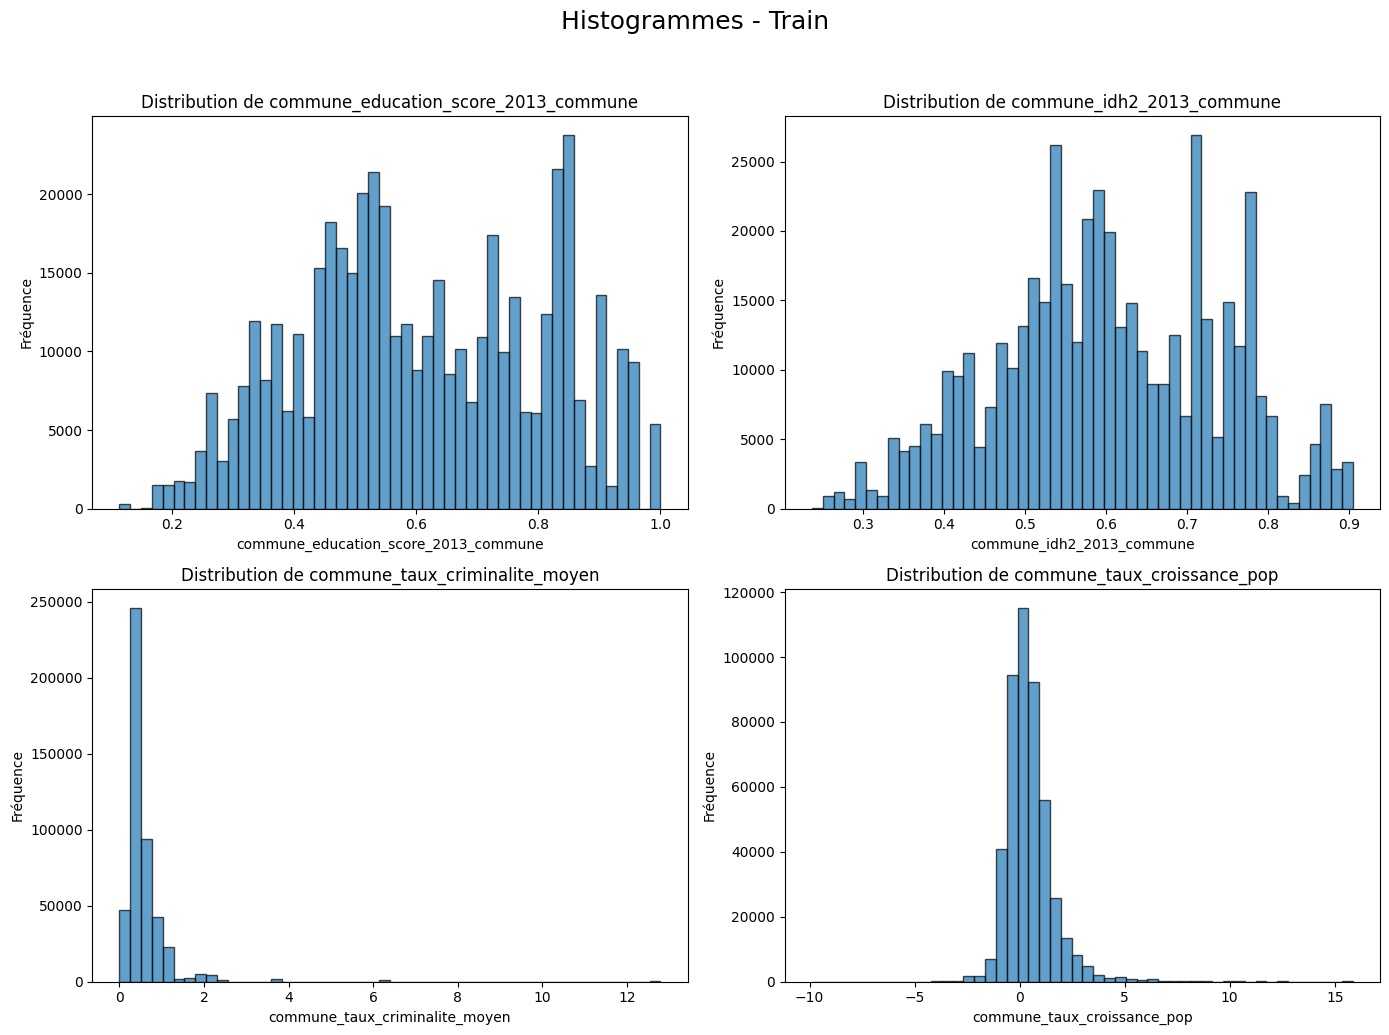

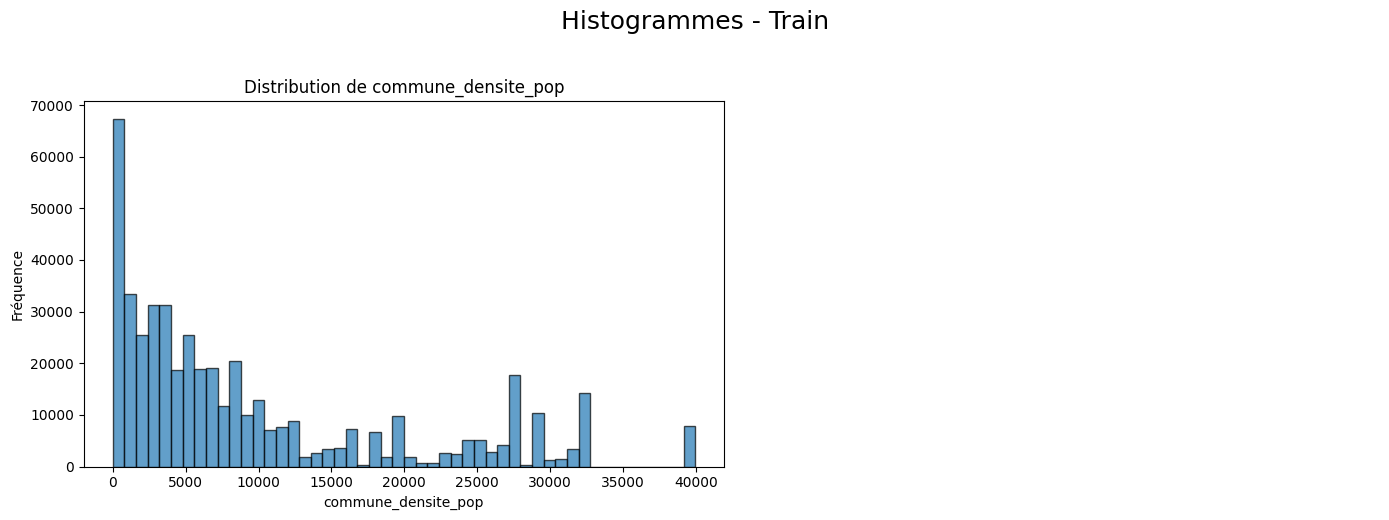

In [26]:
avqt.visualiser_par_batch(train.drop("prix_m2", axis=1), 
                          train["prix_m2"], 
                          [col for col in numerical_dvf_features + numerical_communes_features if col != "prix_m2"], 
                          avqt.plot_histogramme, 
                          "Histogrammes - Train")

#### Valeurs aberrantes

In [27]:
outliers_df = avqt.zscore_outlier_rate(train[numerical_dvf_features + numerical_communes_features].drop("prix_m2", axis=1), threshold=3)
outliers_df

,outlier_rate_%,outlier_min,outlier_max
commune_part_services_entreprises,2.719034,0.003743,3.448278e-01
commune_taux_etablissements_10_plus,2.108813,0.002230,3.482518e-01
commune_taux_residences_secondaires,2.065545,-0.087941,1.632963e-01
valeur_fonciere,2.011407,-549541.375000,1.318598e+06
commune_ratio_residences_secondaires_population,1.919544,-0.102199,1.676662e-01
commune_etablissements_agriculture_2021,1.838550,-9.497905,1.363929e+01
commune_etablissements_1_salarie_2021,1.838550,-6813.255922,1.096837e+04
ecart_prix_median_pct,1.833648,-121.217461,1.338975e+02
commune_taux_criminalite_moyen,1.753720,-0.913941,2.046986e+00
distance_paris,1.681039,-0.347945,7.792176e-01


#### Boxplots 

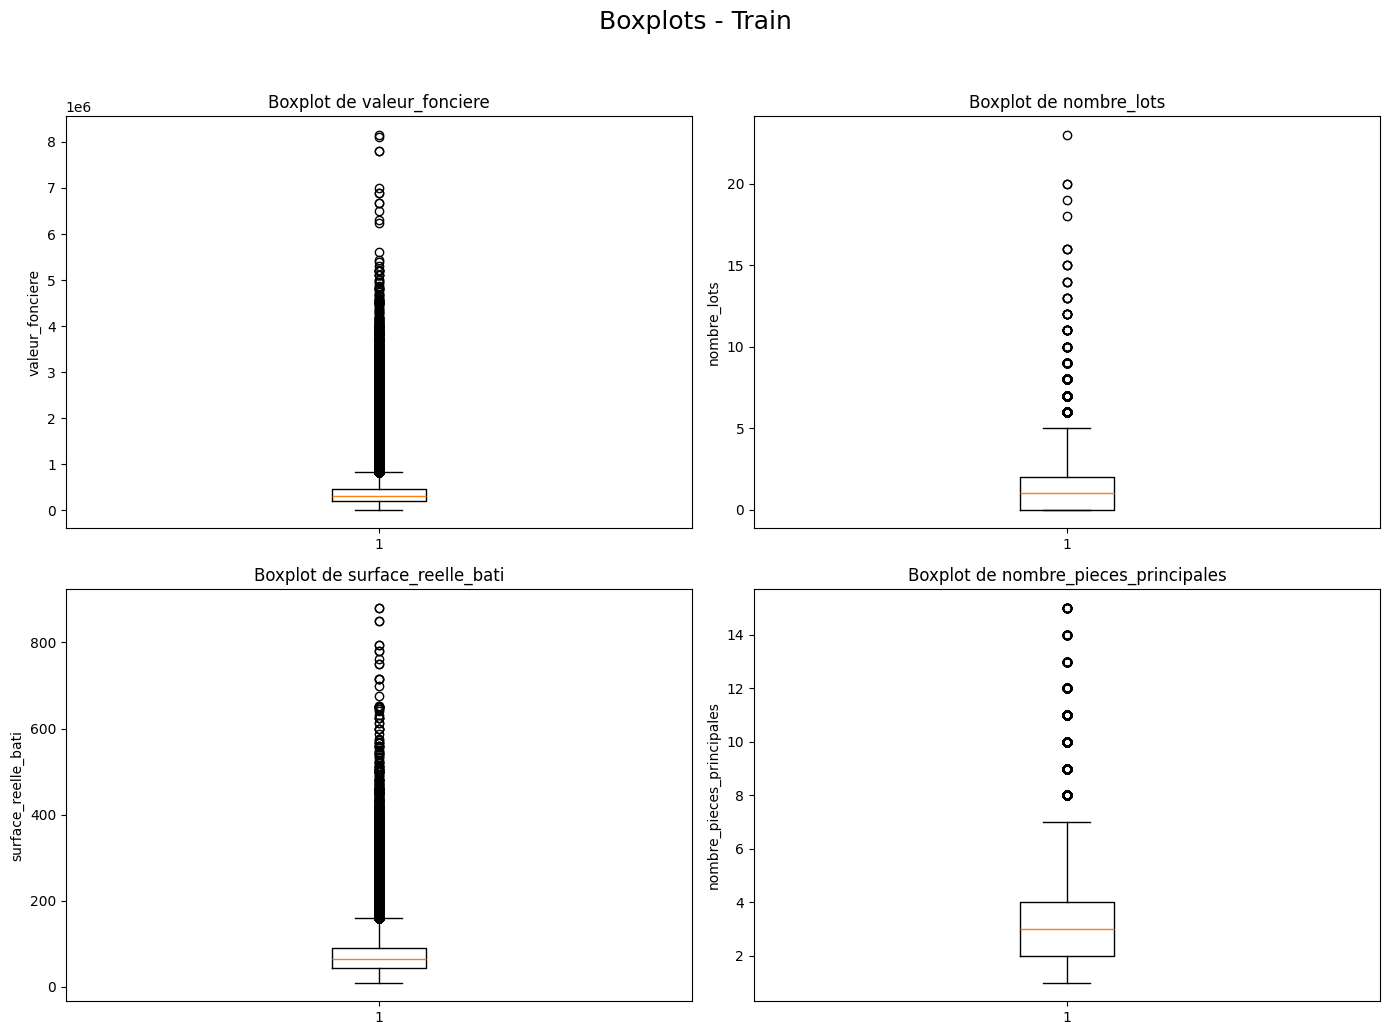

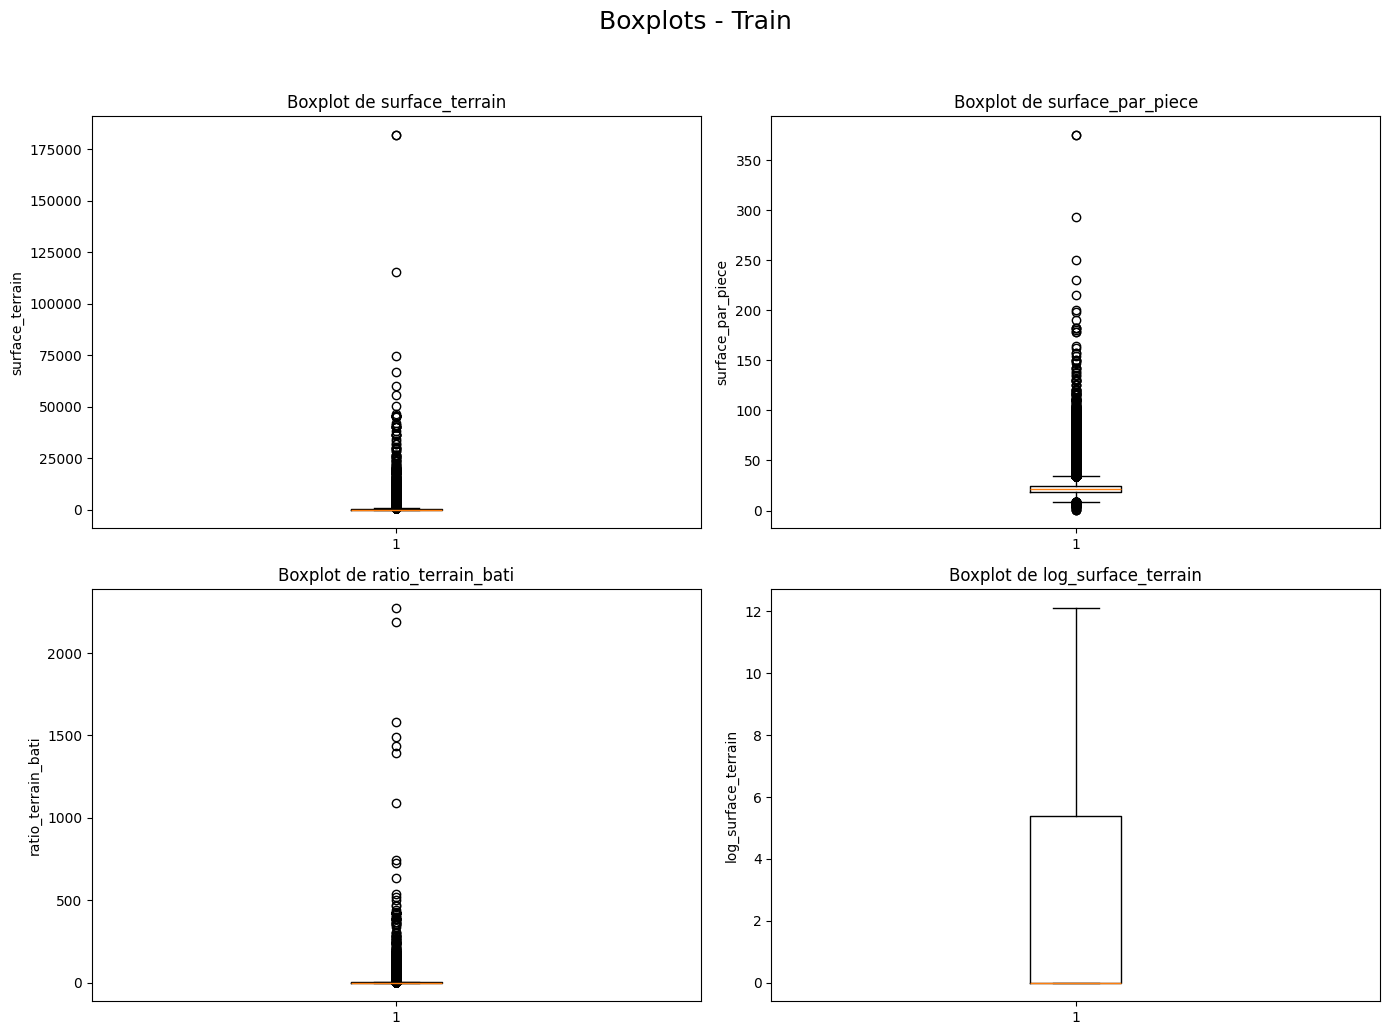

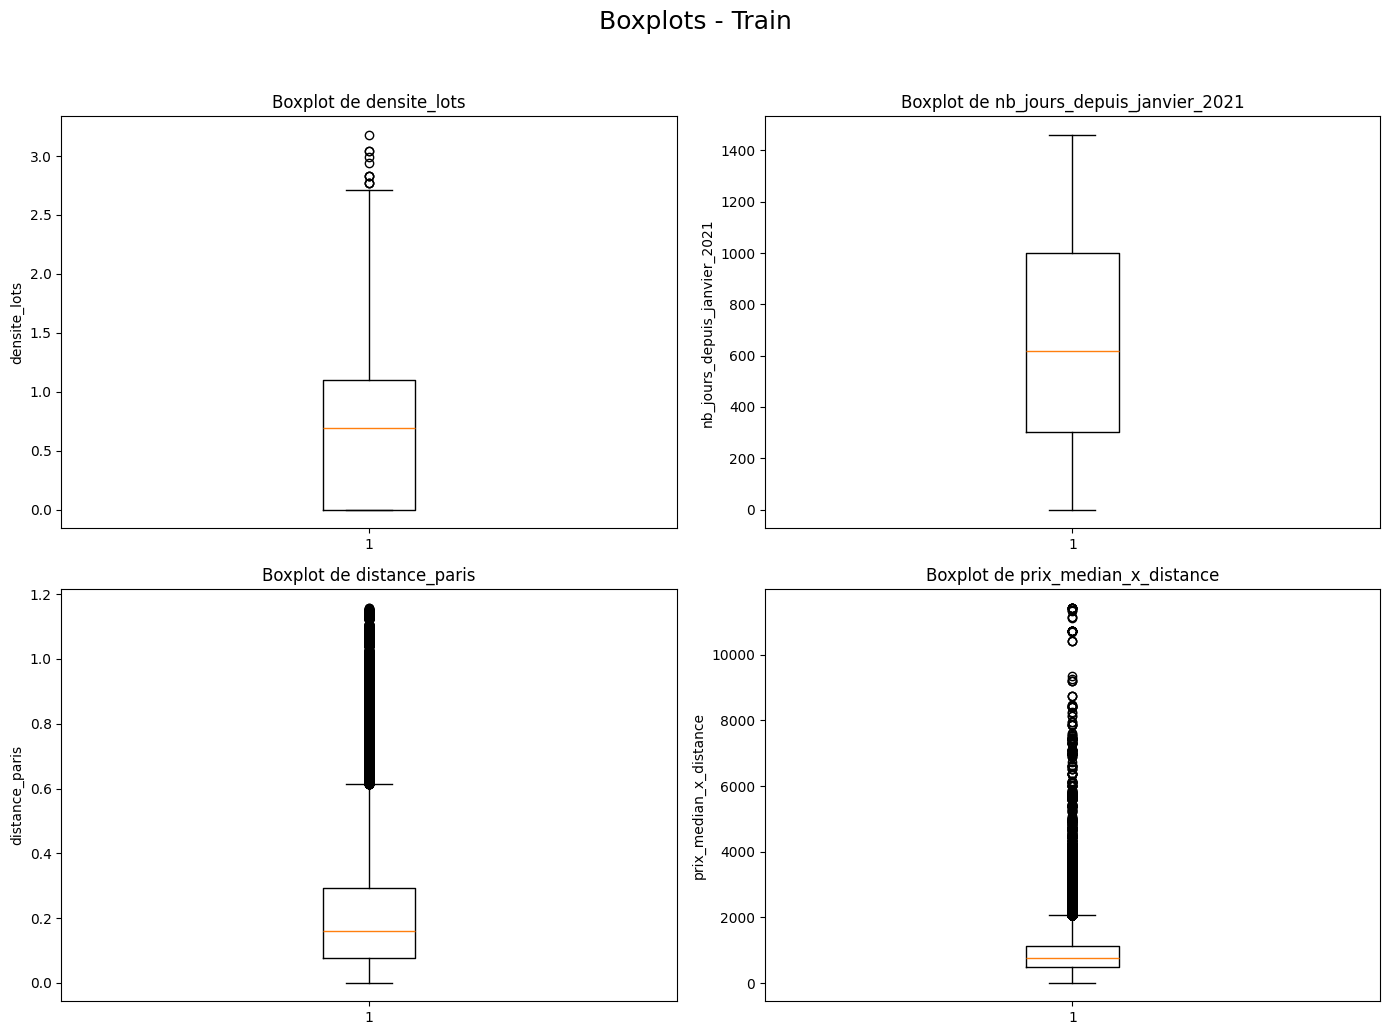

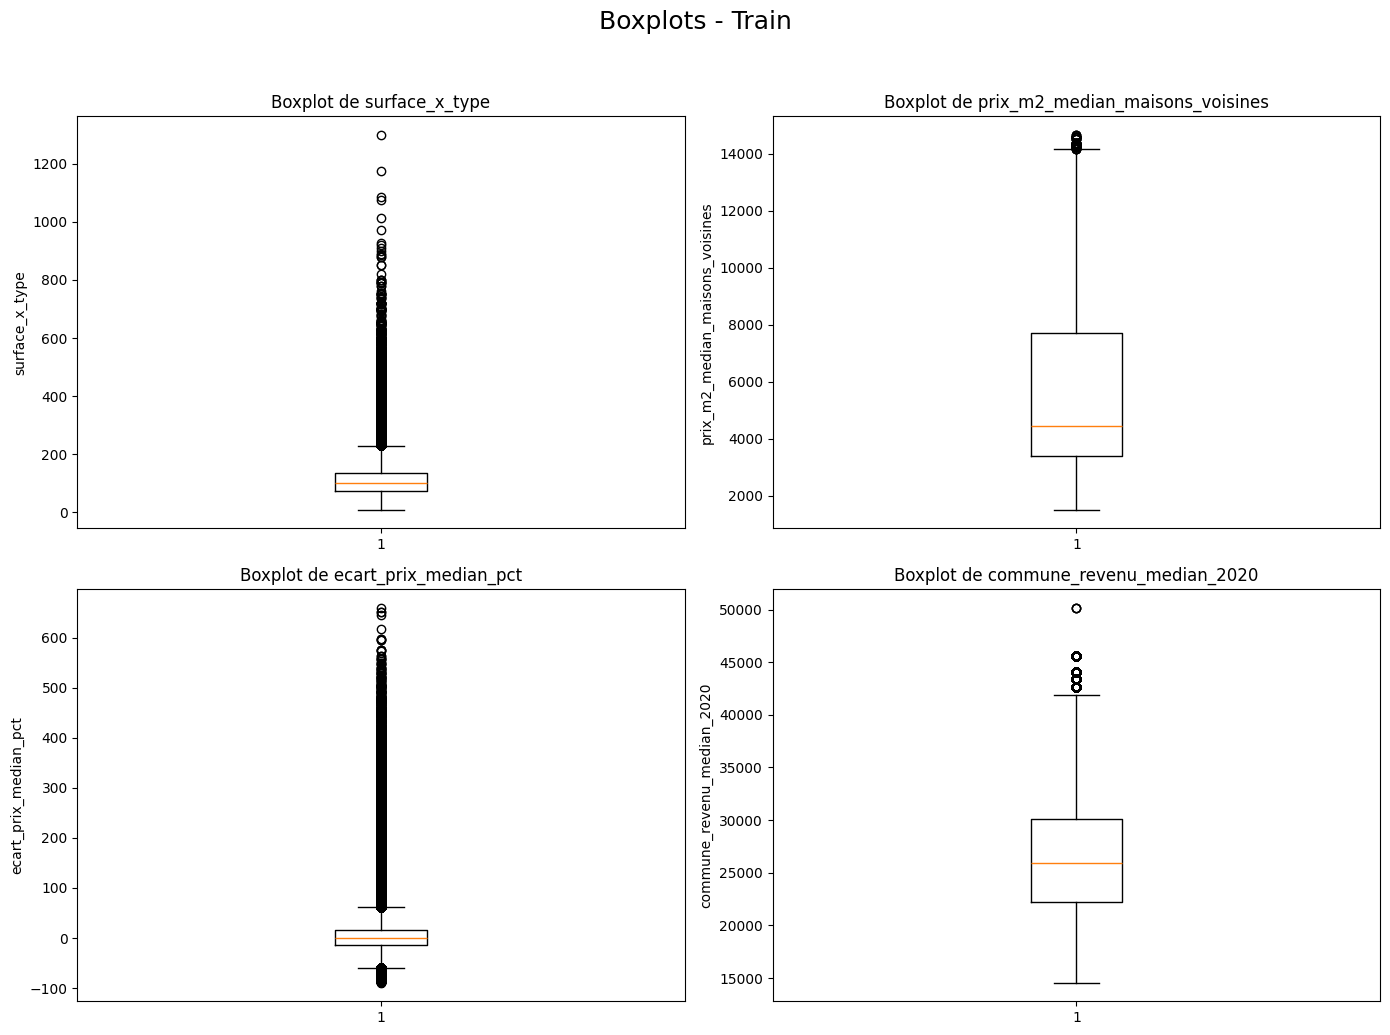

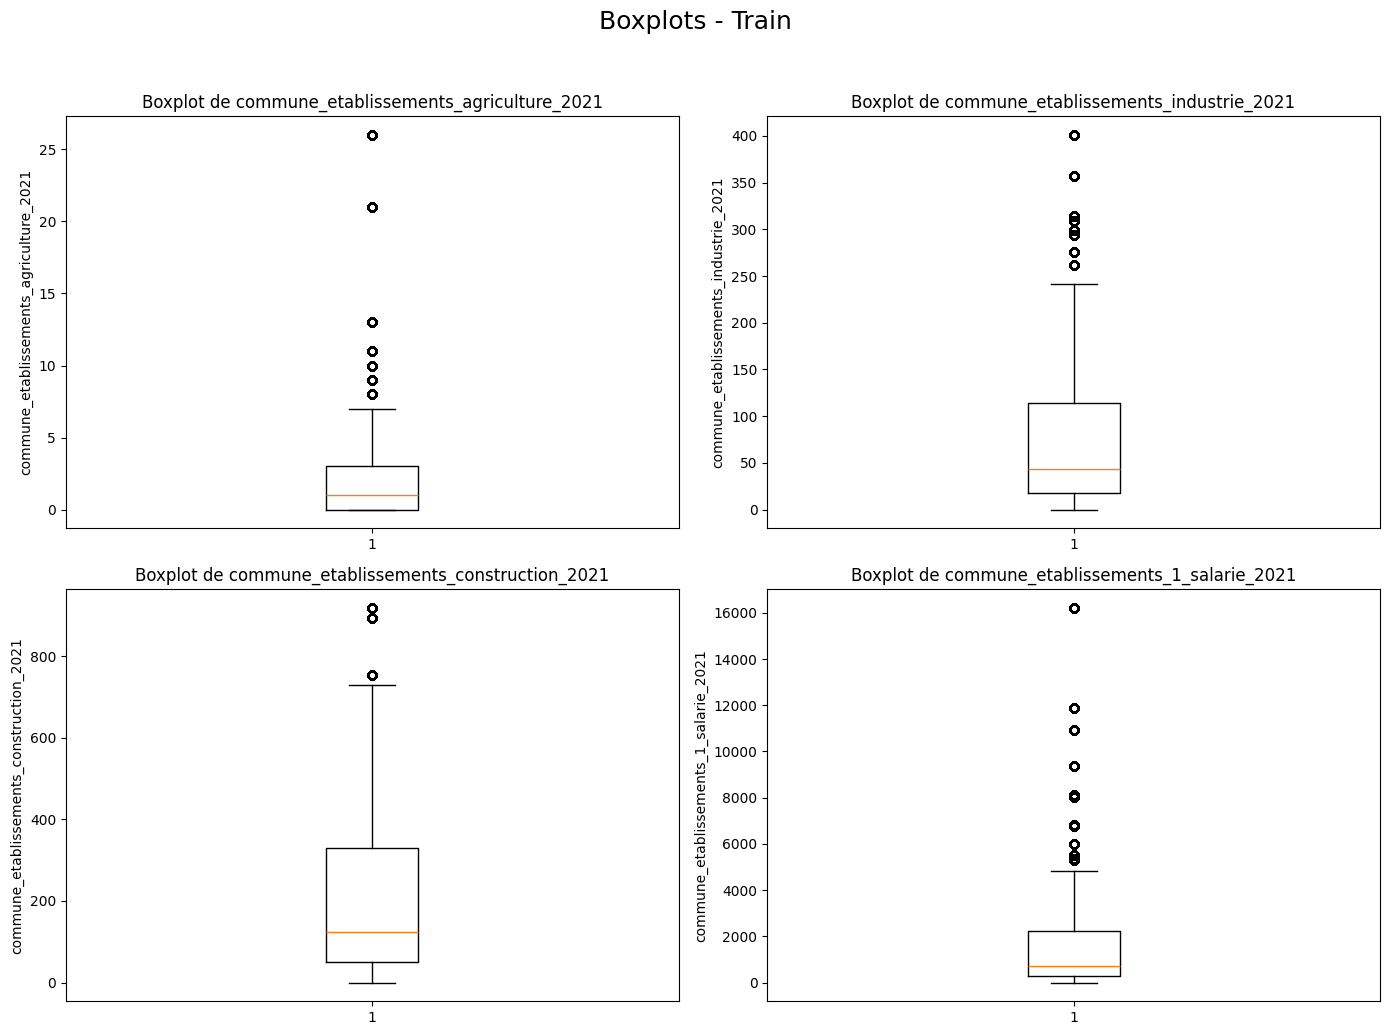

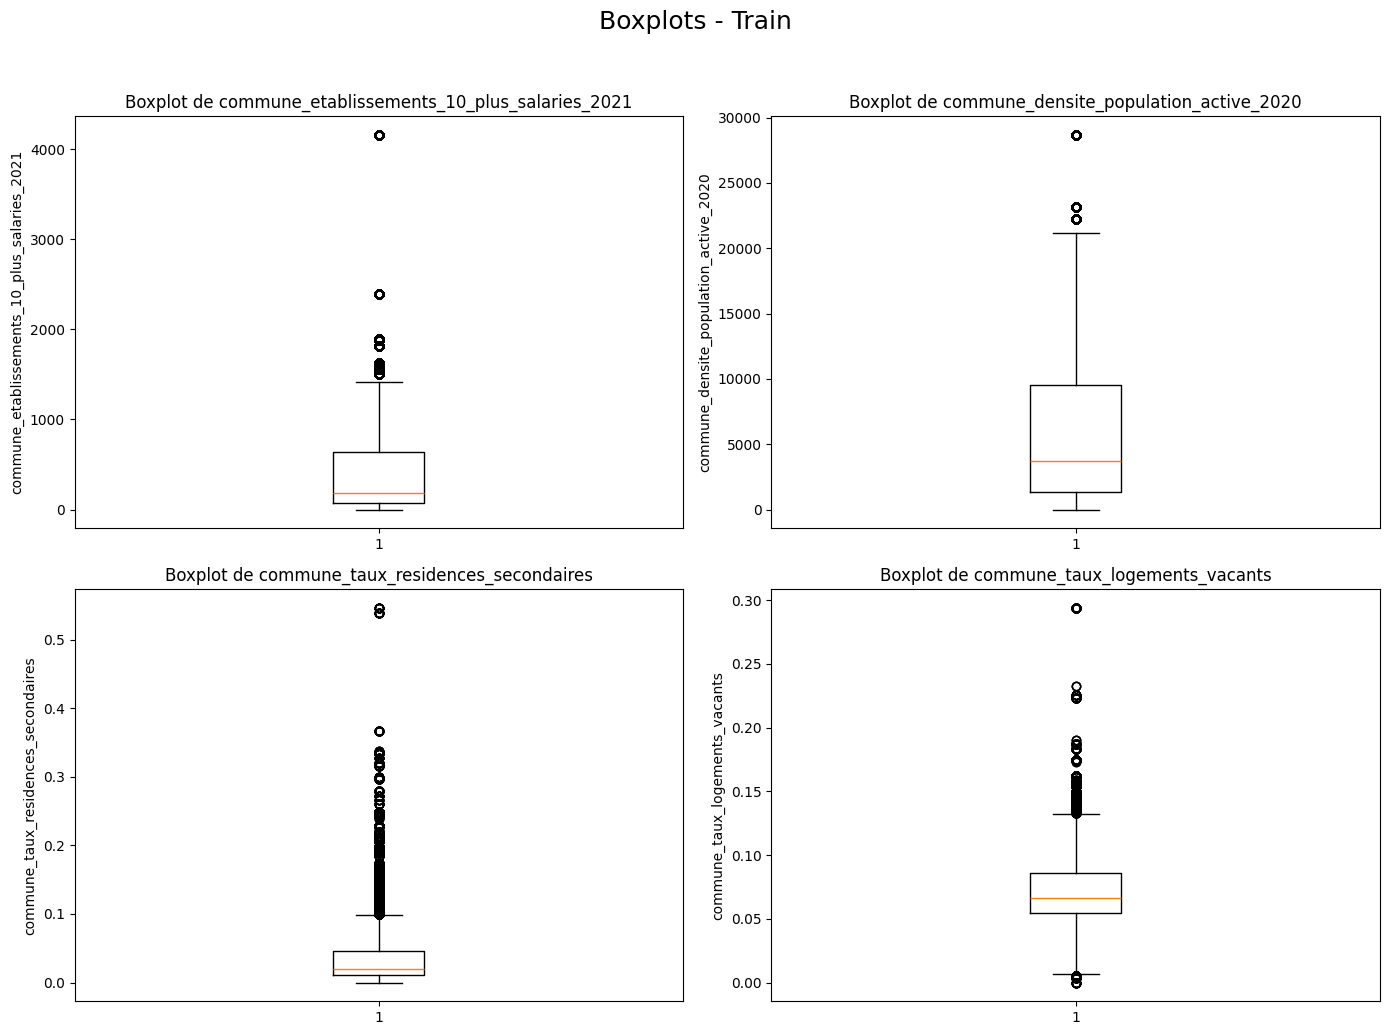

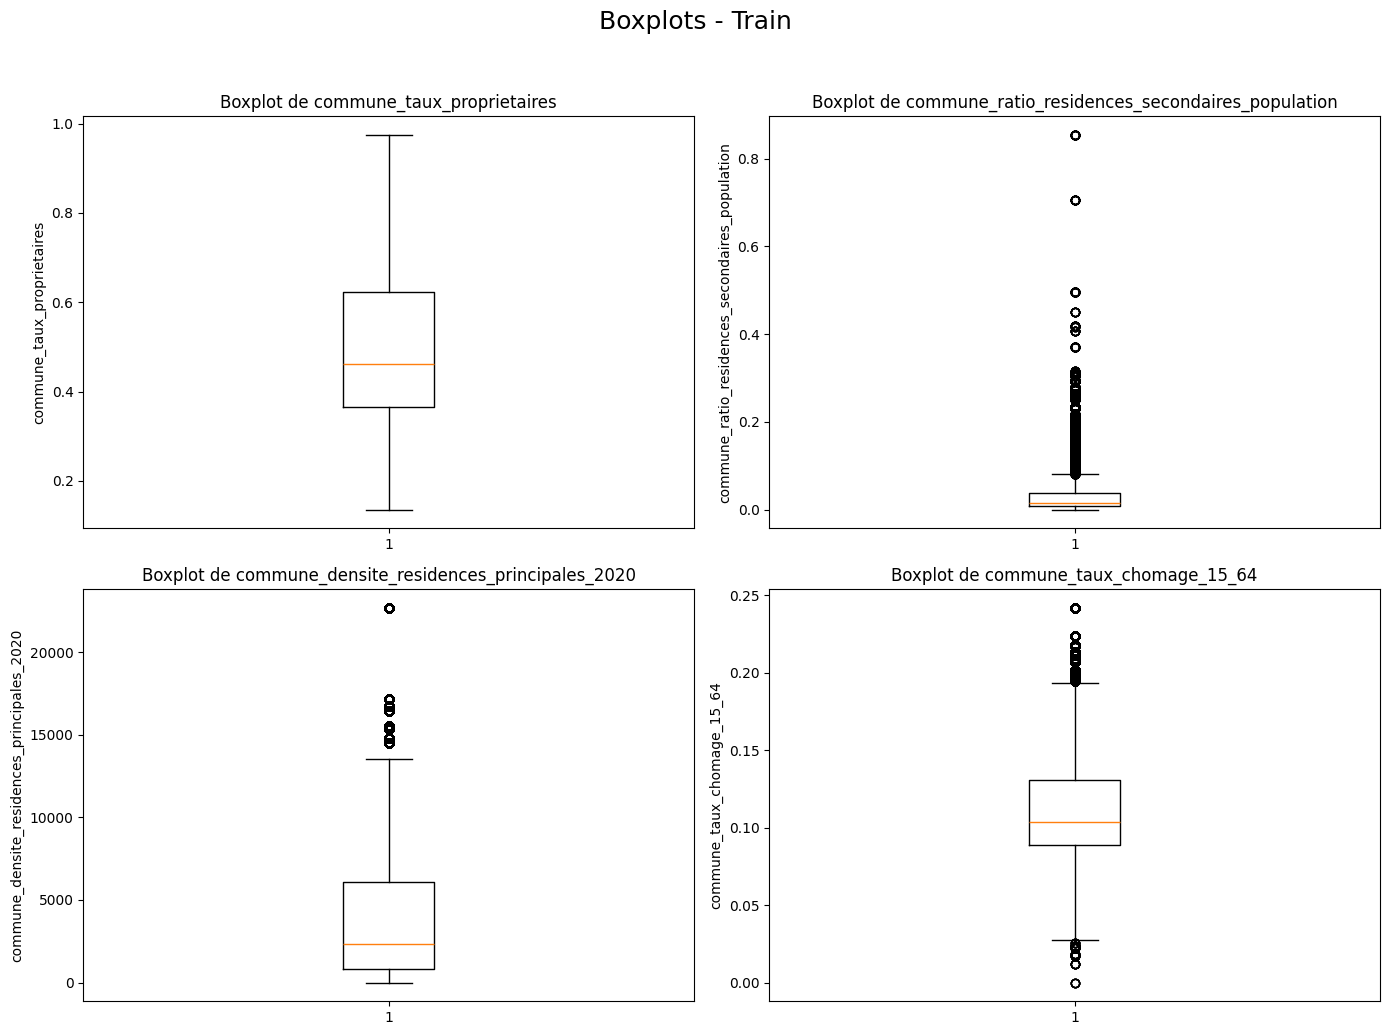

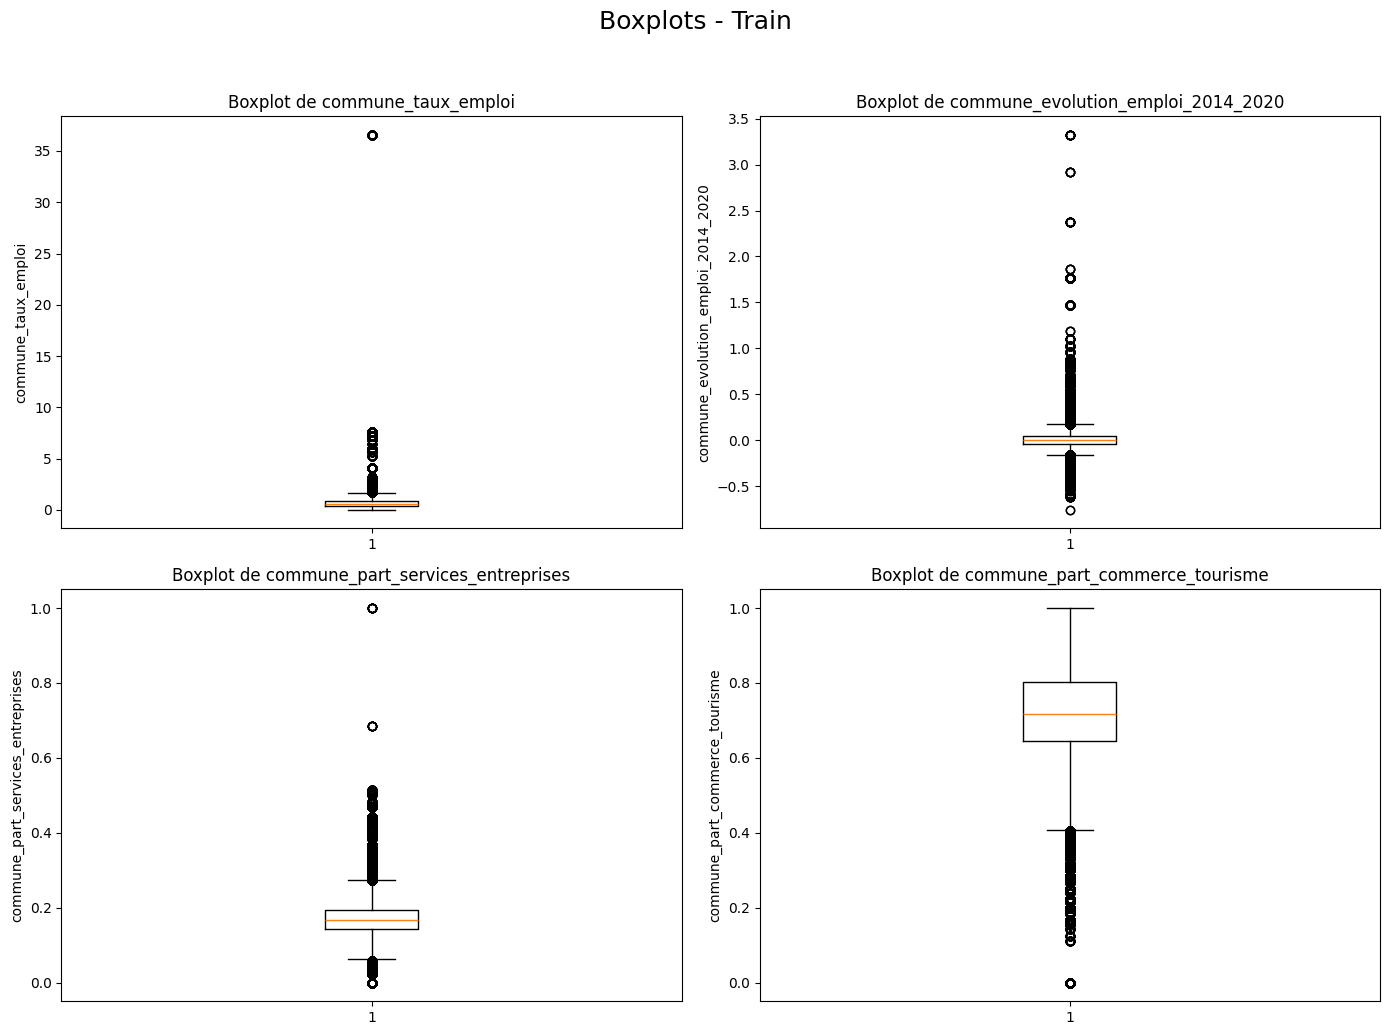

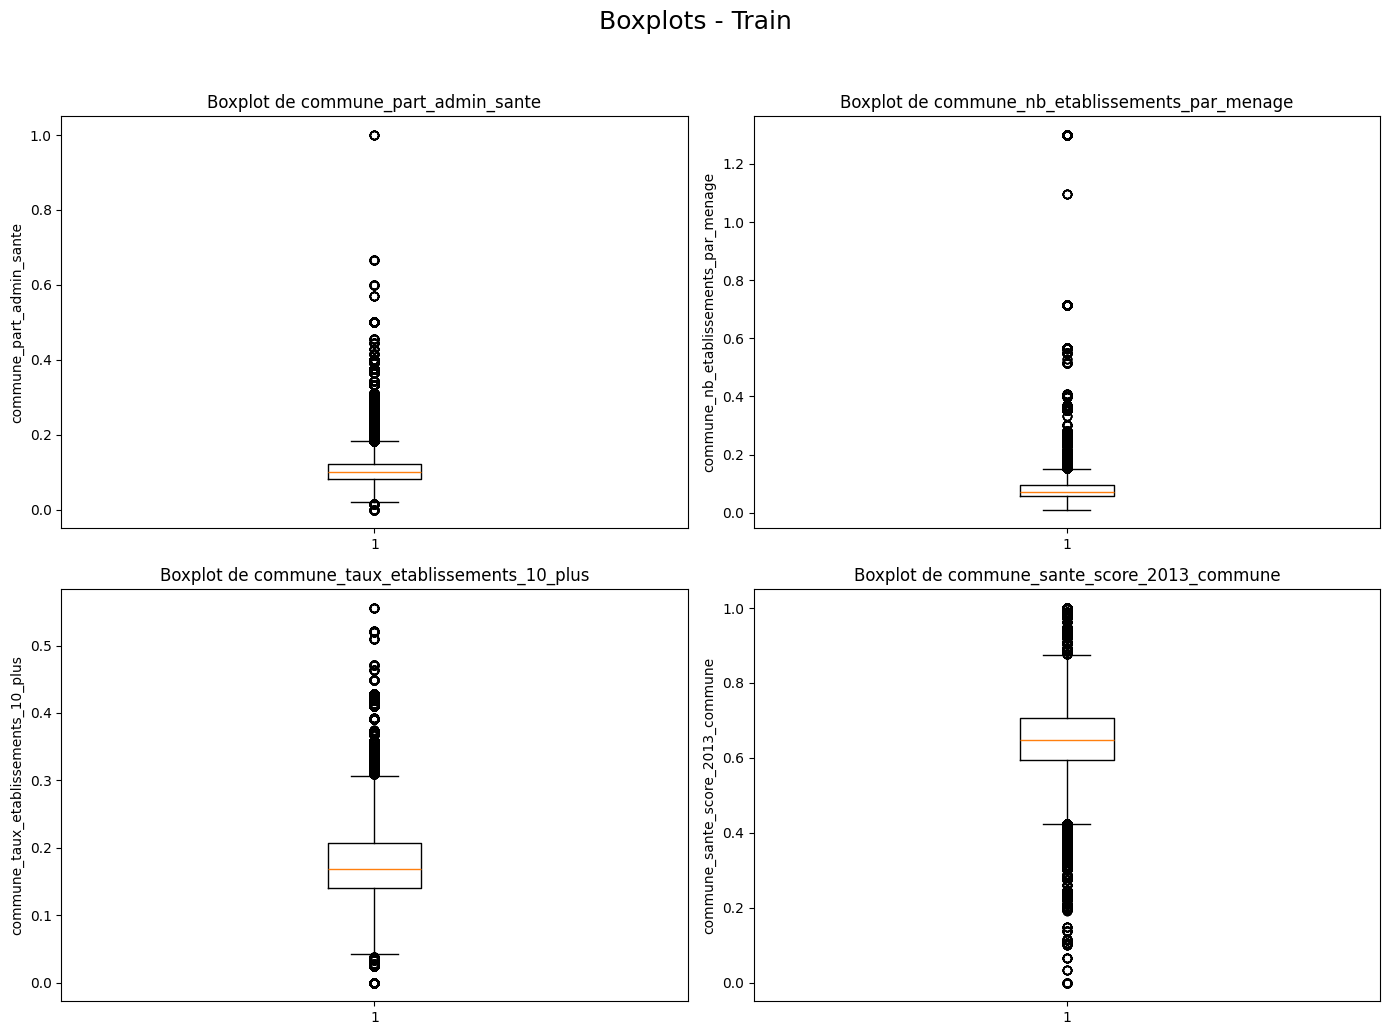

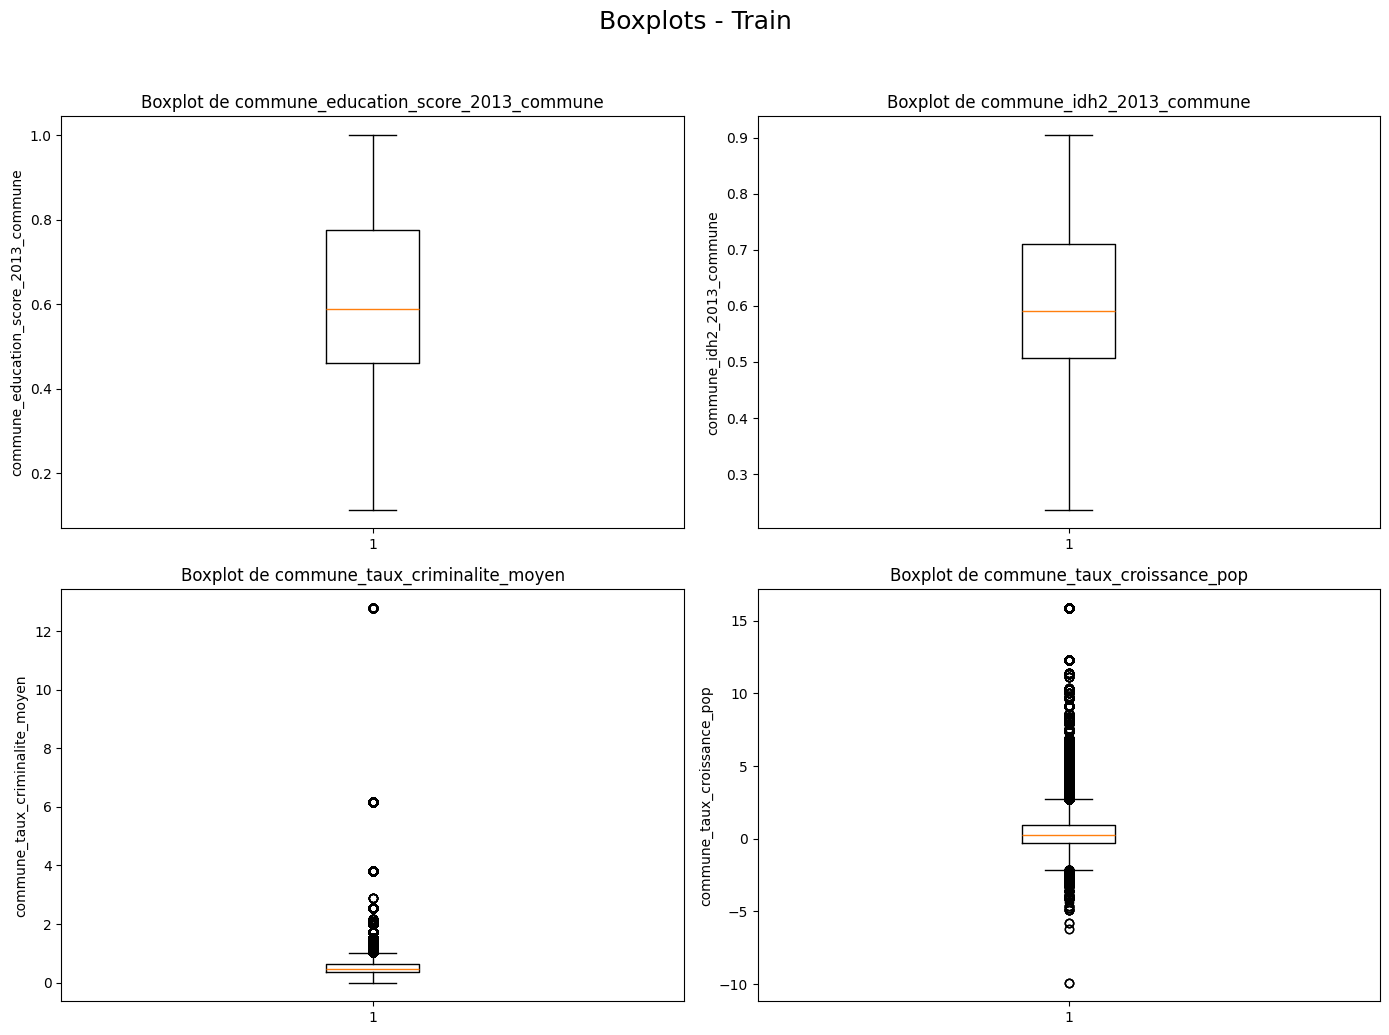

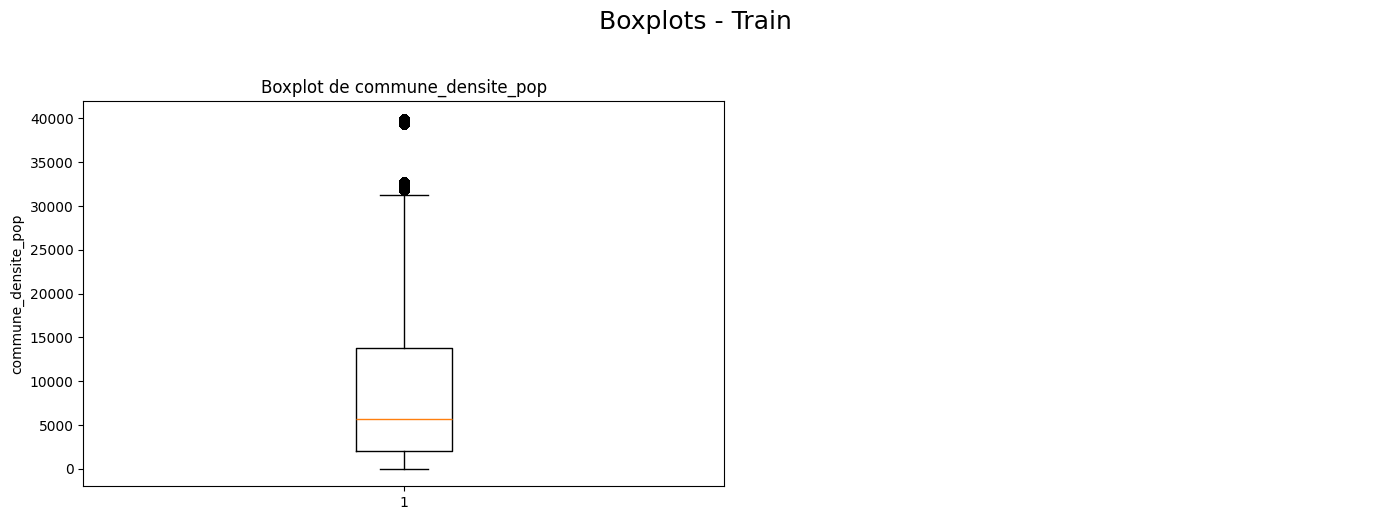

In [28]:
avqt.visualiser_par_batch(train.drop("prix_m2", axis=1), 
                          train["prix_m2"], 
                          [col for col in numerical_dvf_features + numerical_communes_features if col != "prix_m2"],
                          avqt.plot_boxplot,
                          "Boxplots - Train")

#### Nuages de points 

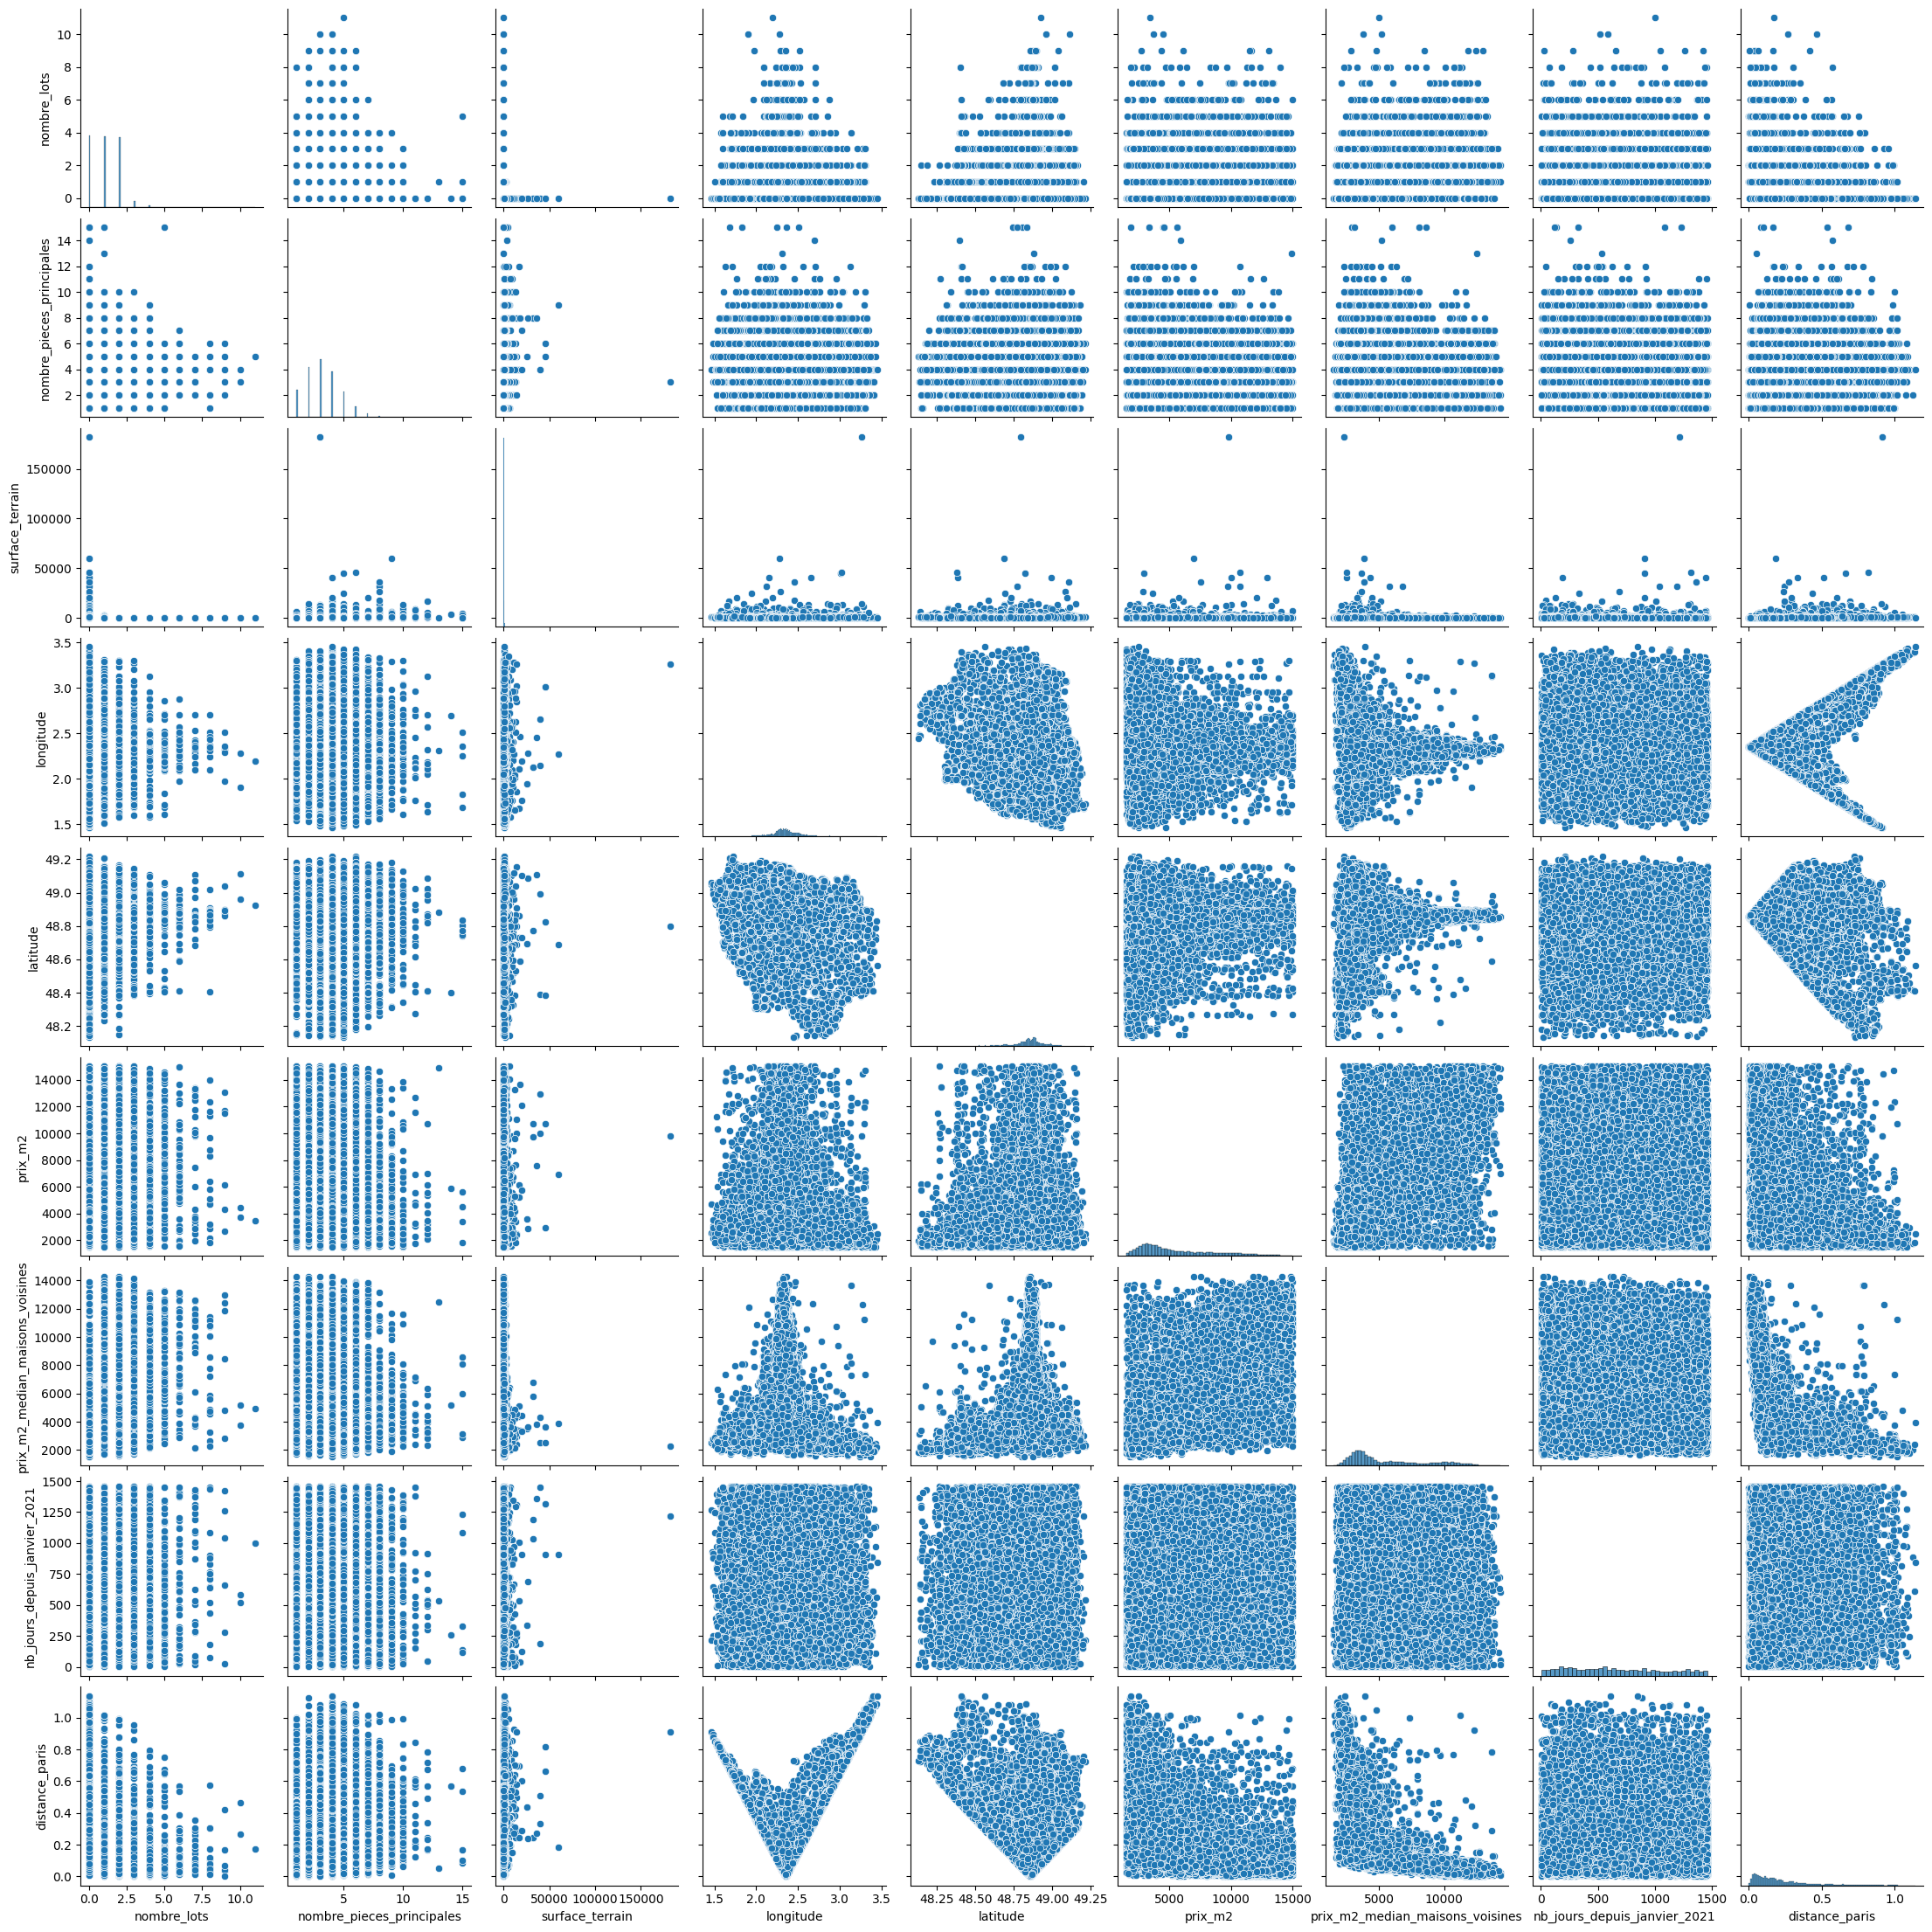

In [29]:
sns.pairplot(train[['nombre_lots',
                    'nombre_pieces_principales',
                    'surface_terrain',
                    'longitude',
                    'latitude',
                    'prix_m2',
                    'prix_m2_median_maisons_voisines',
                    'nb_jours_depuis_janvier_2021',
                    'distance_paris']].sample(frac=0.1, random_state=42))

#### Corrélations

##### 1) Corrélations entre variable de la table DVF 

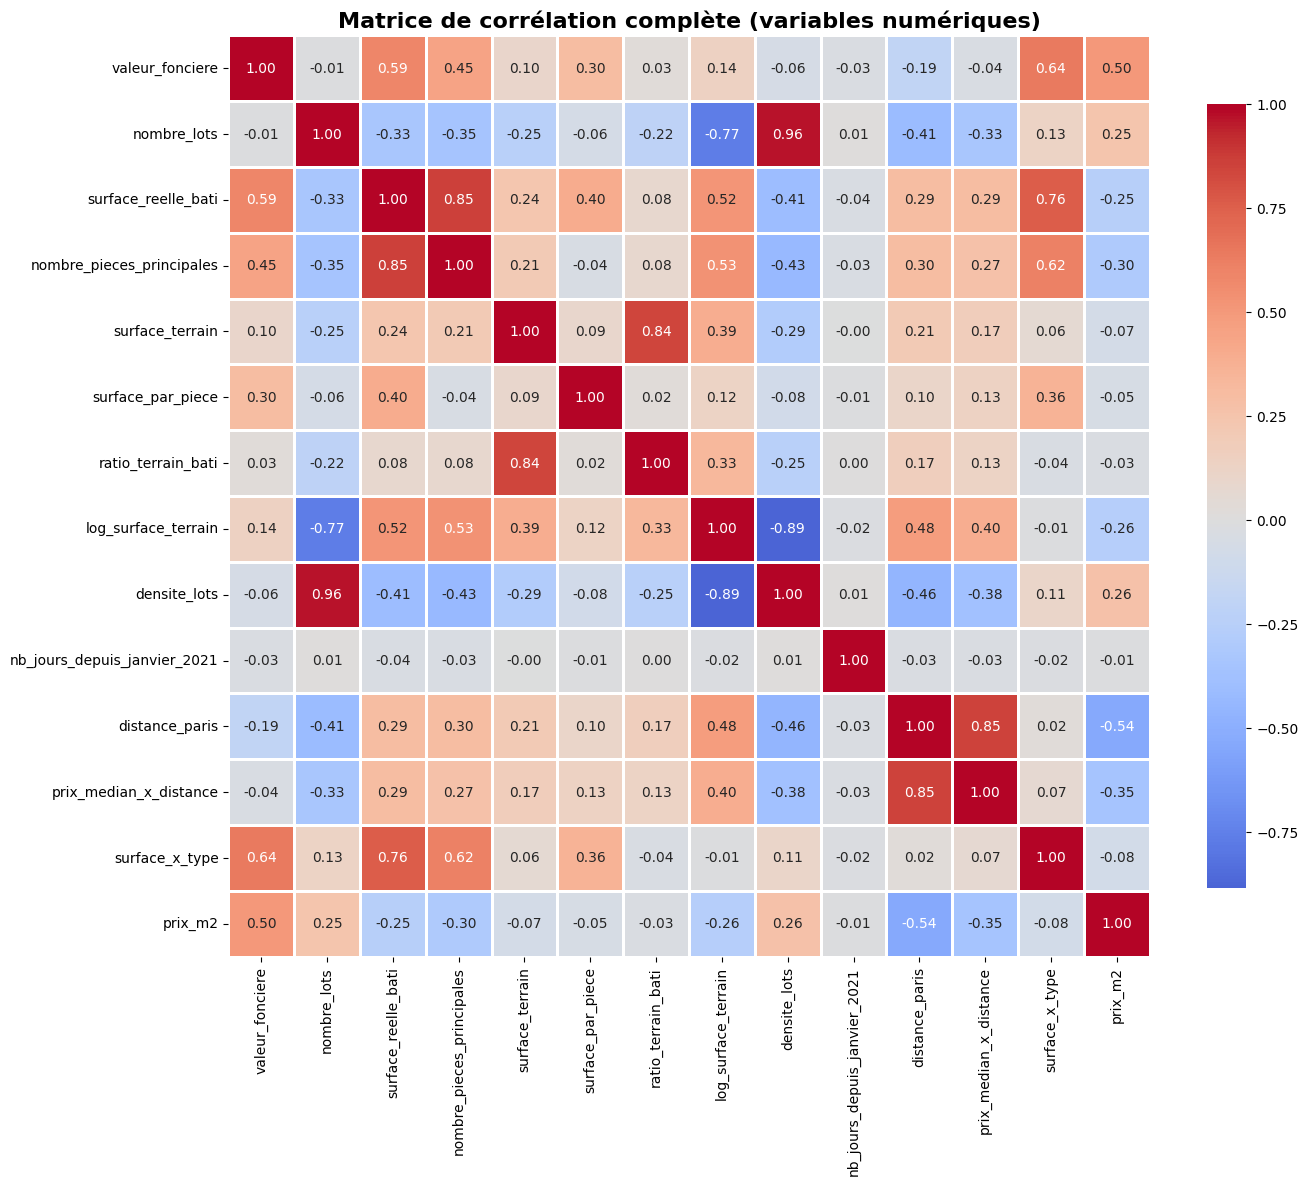

In [30]:
avqt.visualiser_matrice_correlation(train.drop("prix_m2", axis=1),
                                    train["prix_m2"], 
                                    [col for col in numerical_dvf_features if col != "prix_m2"],
                                    annot = True)

##### 2) Corrélations entre indicateurs communaux 

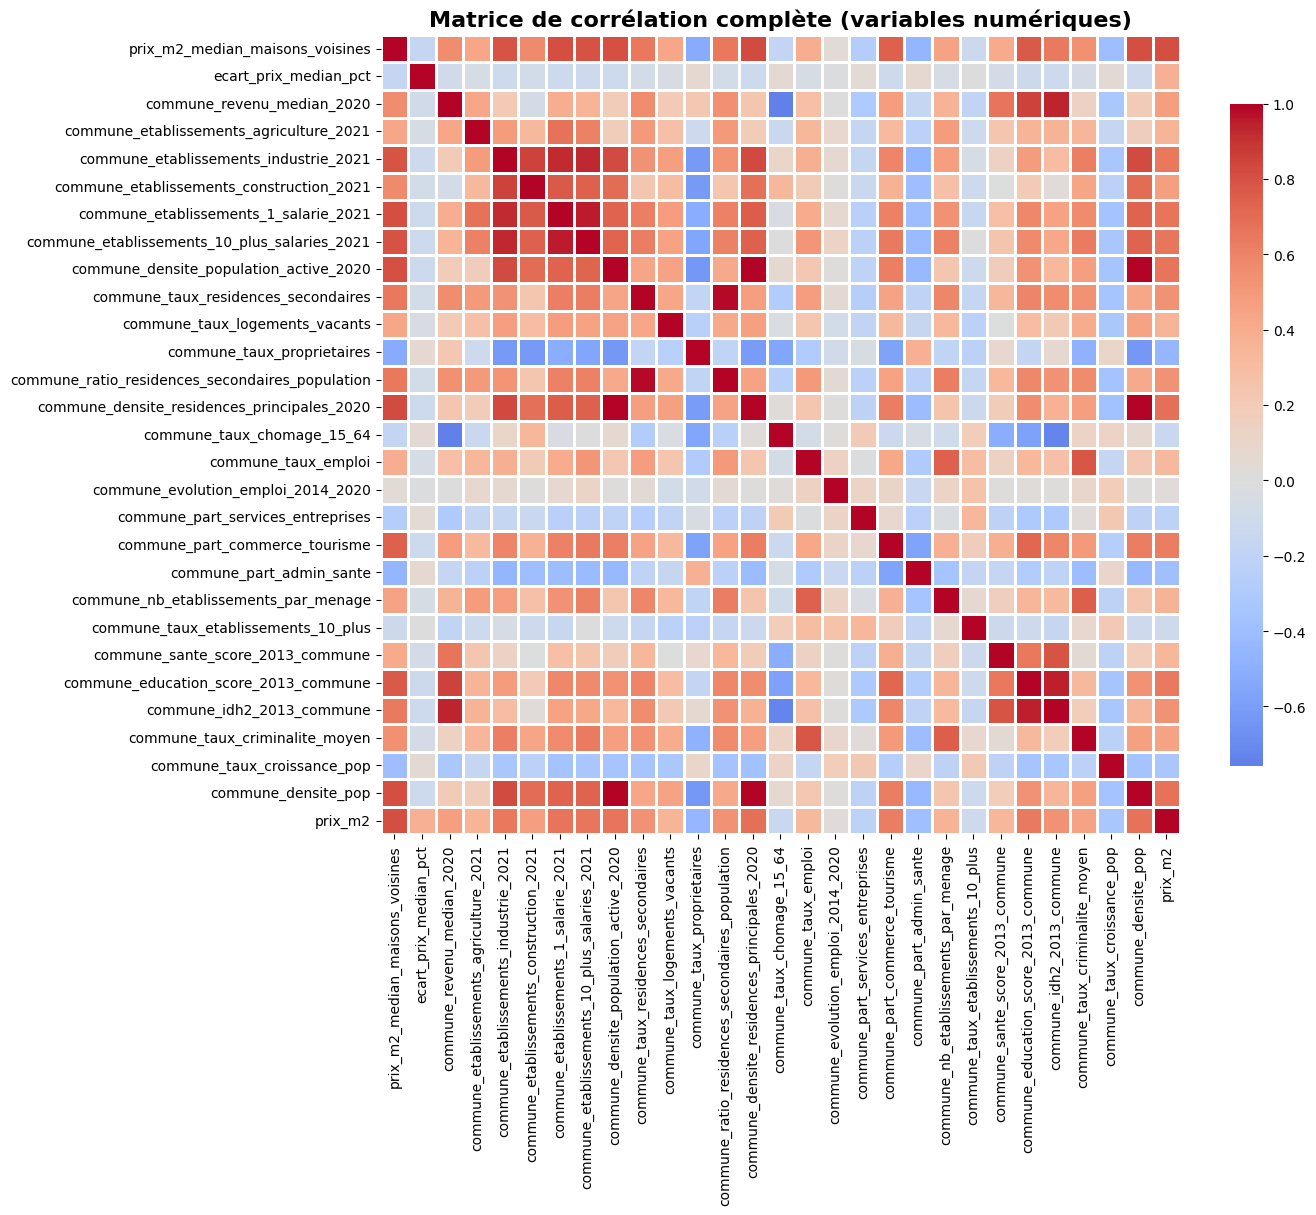

In [31]:
avqt.visualiser_matrice_correlation(train.drop("prix_m2", axis=1),
                                    train["prix_m2"], 
                                    [col for col in numerical_communes_features if col != "prix_m2"],
                                    annot = False)

##### 3) Corrélations entre indicateurs macro 

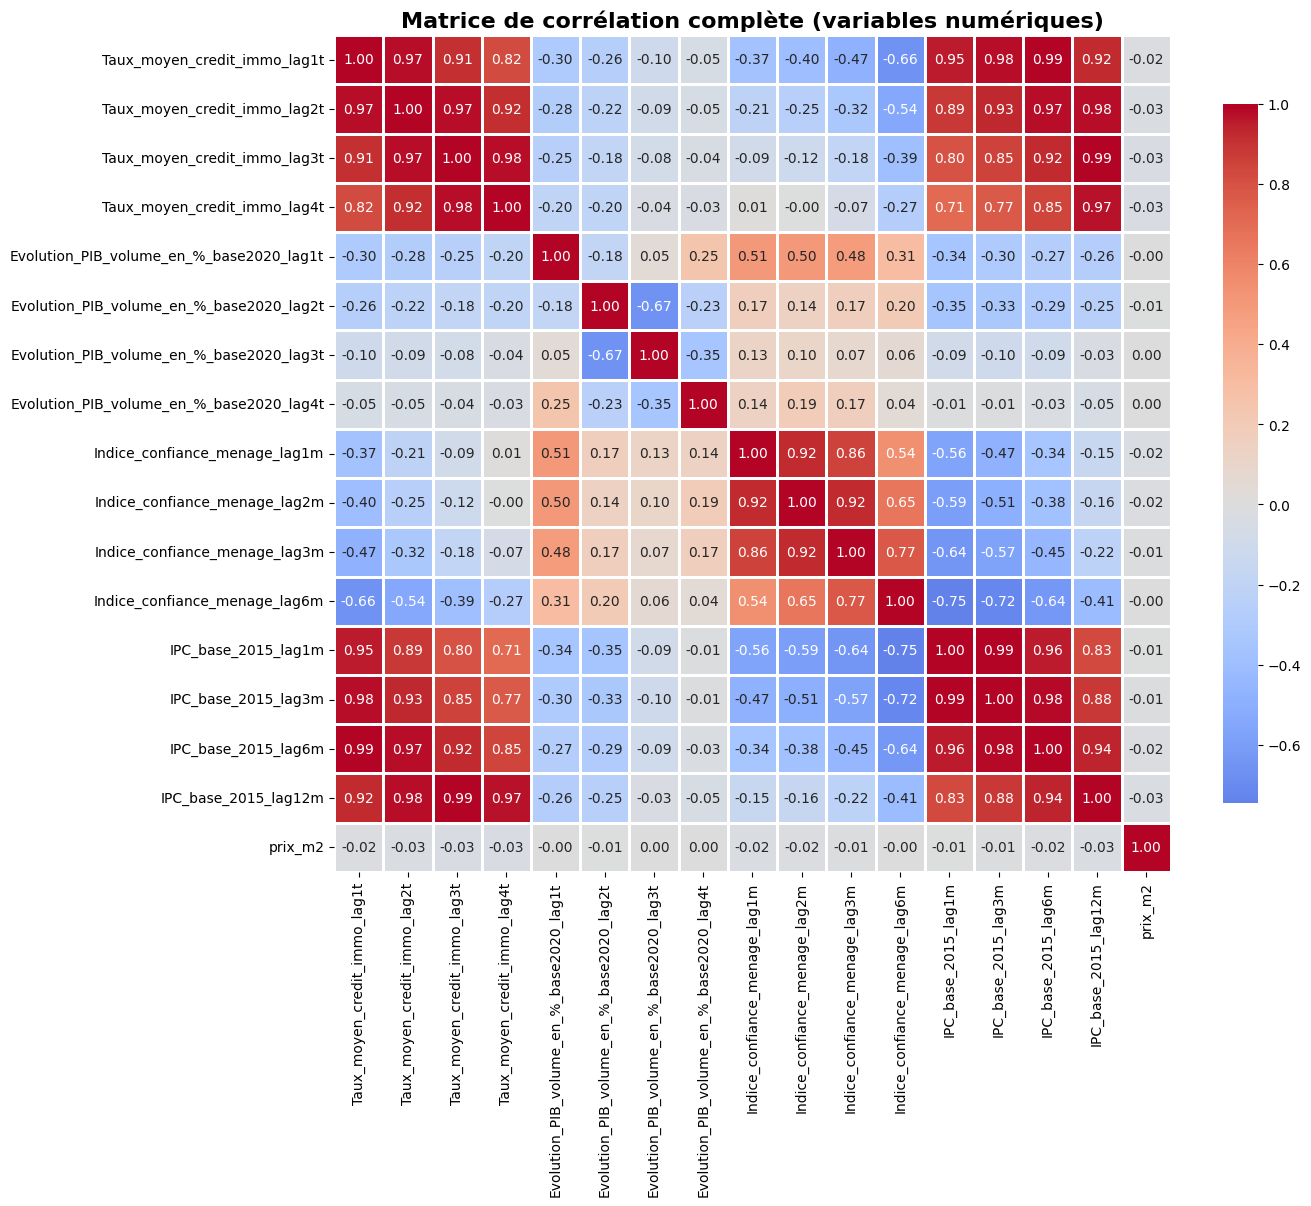

In [32]:
avqt.visualiser_matrice_correlation(train.drop("prix_m2", axis=1),
                                    train["prix_m2"], 
                                    [col for col in numerical_macro_features if col != "prix_m2"],
                                    annot = True)

##### 4) Corrélations entre indicateurs POIs 

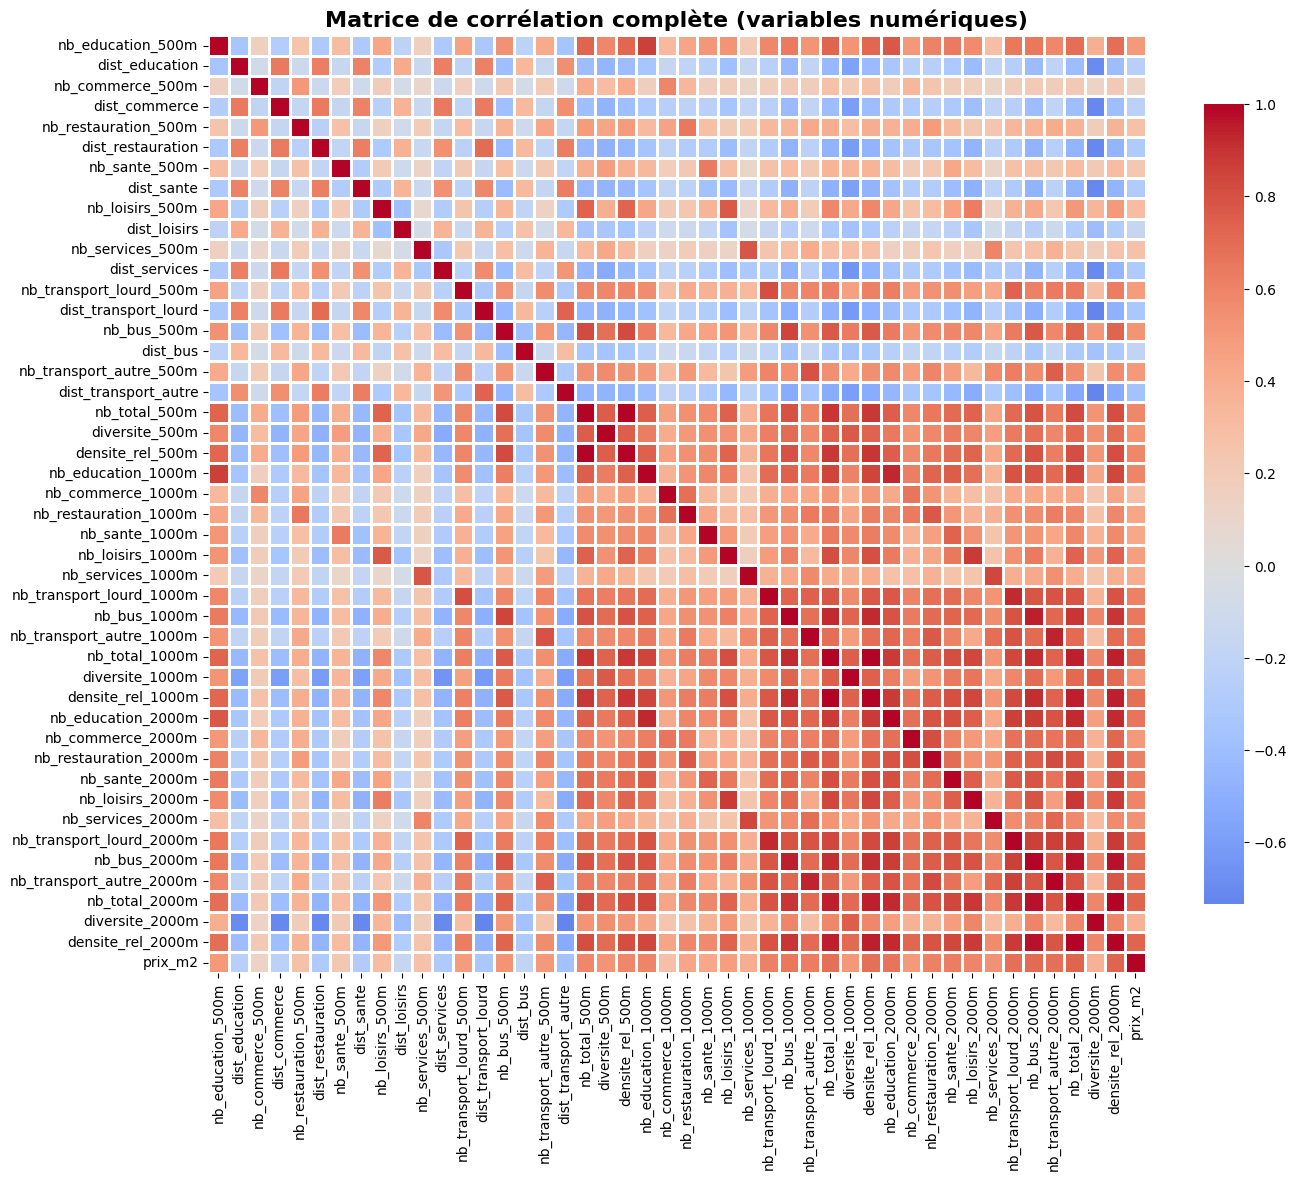

In [33]:
avqt.visualiser_matrice_correlation(train.drop("prix_m2", axis=1),
                                    train["prix_m2"], 
                                    [col for col in numerical_poi_features if col != "prix_m2"],
                                    annot = False)

#### Evolution du prix au mètre carré par trimestre 

In [34]:
# Calculer le prix médian et moyen par trimestre
evolution_prix = train.groupby('trimestre')['prix_m2'].agg(['count', 'median', 'mean']).reset_index()
evolution_prix.columns = ['trimestre', 'nombre_transactions', 'prix_median_m2', 'prix_moyen_m2']

# Graphique 1 : Prix médian et moyen au m² par trimestre
fig_prix = go.Figure()
fig_prix.add_trace(go.Scatter(
    x=evolution_prix['trimestre'],
    y=evolution_prix['prix_median_m2'],
    mode='lines+markers',
    name='Prix médian au m²'
))
fig_prix.add_trace(go.Scatter(
    x=evolution_prix['trimestre'],
    y=evolution_prix['prix_moyen_m2'],
    mode='lines+markers',
    name='Prix moyen au m²'
))
fig_prix.update_layout(
    title="Évolution du prix médian et moyen au m² par trimestre",
    xaxis_title="trimestre",
    yaxis_title="Prix au m² (€)",
    hovermode='x unified',
    legend_title='Indicateur',
    height=400,
    font=dict(size=12)
)
fig_prix.show()

# Graphique 2 : Nombre de transactions par trimestre
fig_tx = go.Figure()
fig_tx.add_trace(go.Scatter(
    x=evolution_prix['trimestre'],
    y=evolution_prix['nombre_transactions'],
    mode='lines+markers',
    name='Nombre de transactions'
))
fig_tx.update_layout(
    title="Nombre de transactions par trimestre",
    xaxis_title="trimestre",
    yaxis_title="Nombre de transactions",
    hovermode='x unified',
    height=400,
    font=dict(size=12)
)
fig_tx.show()

C:\Users\leoco\AppData\Local\Temp\ipykernel_1920\1663386363.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [35]:
serie_inflation = pd.read_csv("data/raw/series_macro/indice_prix_conso.csv", sep=";")
serie_inflation = serie_inflation.drop(columns="Codes")
serie_inflation = serie_inflation.drop(index=[0, 1, 2])
serie_inflation["Libellé"] = pd.to_datetime(serie_inflation["Libellé"], format="%Y-%m")
serie_inflation["Libellé"] = serie_inflation["Libellé"].dt.to_period('Q')
serie_inflation["Libellé"] = serie_inflation["Libellé"].astype(str).str.replace("Q1", "-T1").str.replace("Q2", "-T2").str.replace("Q3", "-T3").str.replace("Q4", "-T4")
serie_inflation.head(3)

,Libellé,Indice des prix à la consommation - Base 2015 - Ensemble des ménages - France - Alimentation
3,2025-T4,133.48
4,2025-T3,133.79
5,2025-T3,134.05


In [36]:
evolution_prix.head(3)

,trimestre,nombre_transactions,prix_median_m2,prix_moyen_m2
0,2021-T1,28822,4532.834473,5742.823242
1,2021-T2,34960,4521.209961,5734.201660
2,2021-T3,41163,4576.270996,5749.931152


In [37]:
merged_df = pd.merge(
    evolution_prix,
    serie_inflation,
    left_on='trimestre',
    right_on='Libellé',
    how='left'
)

merged_df = merged_df[["trimestre", "prix_median_m2", "Indice des prix à la consommation - Base 2015 - Ensemble des ménages - France - Alimentation"]]
merged_df.head(3)

,trimestre,prix_median_m2,Indice des prix à la consommation - Base 2015 - Ensemble des ménages - France - Alimentation
0,2021-T1,4532.834473,108.24
1,2021-T1,4532.834473,108.19
2,2021-T1,4532.834473,108.4


In [38]:
fig_compare = go.Figure()

# Axe 1 : prix_median_m2
fig_compare.add_trace(go.Scatter(
    x=merged_df['trimestre'],
    y=merged_df['prix_median_m2'],
    name='Prix médian au m²',
    mode='lines+markers',
    yaxis='y1'
))

# Axe 2 : Indice des prix à la consommation
fig_compare.add_trace(go.Scatter(
    x=merged_df['trimestre'],
    y=merged_df['Indice des prix à la consommation - Base 2015 - Ensemble des ménages - France - Alimentation'],
    name='Indice des prix à la consommation',
    mode='lines+markers',
    yaxis='y2'
))

fig_compare.update_layout(
    title="Comparaison Prix médian au m² et Indice des prix à la consommation",
    xaxis=dict(title="Trimestre"),
    yaxis=dict(
        title="Prix médian au m² (€)",
        side='left'
    ),
    yaxis2=dict(
        title="Indice des prix à la consommation",
        overlaying='y',
        side='right'
    ),
    legend=dict(x=0.01, y=0.99),
    height=500,
    font=dict(size=12)
)

fig_compare.show()

# 3.2 Analyse des variables catégorielles 

In [39]:
categorical_features = train.select_dtypes(include=['category']).columns.to_list()

In [40]:
train[categorical_features]

,code_departement,type_local,trimestre,nord_paris,est_paris,sud_paris,ouest_paris
0,75,Appartement,2021-T1,1,1,0,0
1,92,Appartement,2021-T2,0,0,1,1
2,75,Appartement,2022-T3,0,0,1,1
3,75,Appartement,2021-T1,0,1,1,0
4,77,Maison,2022-T4,0,1,1,0
...,...,...,...,...,...,...,...
469169,77,Appartement,2022-T3,0,1,1,0
469170,78,Maison,2021-T3,0,0,1,1
469171,77,Maison,2022-T2,0,1,1,0
469172,78,Maison,2021-T2,1,0,0,1


In [41]:
train[categorical_features]["type_local"].value_counts(dropna=False, normalize=True) * 100

type_local
Appartement    67.391629
Maison         32.608371
Name: proportion, dtype: float64

In [42]:
train = one_hot_encode_type_local(train)
train


,date_mutation,valeur_fonciere,code_commune,nom_commune,code_departement,nombre_lots,type_local,surface_reelle_bati,nombre_pieces_principales,surface_terrain,...,nb_jours_depuis_janvier_2021,distance_paris,nord_paris,est_paris,sud_paris,ouest_paris,prix_median_x_distance,surface_x_type,is_maison,is_appartement
0,2021-02-18,453000.0,75110,Paris 10e Arrondissement,75,1,Appartement,48,3,0.0,...,48,0.022898,1,1,0,0,251.875809,96,0,1
1,2021-06-16,210000.0,92007,Bagneux,92,2,Appartement,45,3,0.0,...,166,0.067297,0,0,1,1,400.319183,90,0,1
2,2022-07-11,640000.0,75105,Paris 5e Arrondissement,75,2,Appartement,51,2,0.0,...,556,0.012333,0,0,1,1,159.726929,102,0,1
3,2021-03-26,1530000.0,75104,Paris 4e Arrondissement,75,1,Appartement,120,3,0.0,...,84,0.010092,0,1,1,0,130.780746,240,0,1
4,2022-12-05,325000.0,77296,Moissy-Cramayel,77,0,Maison,88,5,196.0,...,703,0.337793,0,1,1,0,1062.413452,88,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469169,2022-08-24,110000.0,77014,Avon,77,2,Appartement,70,4,0.0,...,600,0.586708,0,1,1,0,1287.721924,140,0,1
469170,2021-09-03,334700.0,78168,Coignières,78,0,Maison,103,5,474.0,...,245,0.445244,0,0,1,1,1504.184082,103,1,0
469171,2022-05-06,215000.0,77261,Lorrez-le-Bocage-Préaux,77,0,Maison,110,4,850.0,...,490,0.827513,0,1,1,0,1617.224731,110,1,0
469172,2021-06-09,333000.0,78029,Aubergenville,78,0,Maison,85,5,244.0,...,159,0.512374,1,0,0,1,1725.429565,85,1,0


# 4. Suppression des variables inutiles pour la modélisation :

In [43]:
train

,date_mutation,valeur_fonciere,code_commune,nom_commune,code_departement,nombre_lots,type_local,surface_reelle_bati,nombre_pieces_principales,surface_terrain,...,nb_jours_depuis_janvier_2021,distance_paris,nord_paris,est_paris,sud_paris,ouest_paris,prix_median_x_distance,surface_x_type,is_maison,is_appartement
0,2021-02-18,453000.0,75110,Paris 10e Arrondissement,75,1,Appartement,48,3,0.0,...,48,0.022898,1,1,0,0,251.875809,96,0,1
1,2021-06-16,210000.0,92007,Bagneux,92,2,Appartement,45,3,0.0,...,166,0.067297,0,0,1,1,400.319183,90,0,1
2,2022-07-11,640000.0,75105,Paris 5e Arrondissement,75,2,Appartement,51,2,0.0,...,556,0.012333,0,0,1,1,159.726929,102,0,1
3,2021-03-26,1530000.0,75104,Paris 4e Arrondissement,75,1,Appartement,120,3,0.0,...,84,0.010092,0,1,1,0,130.780746,240,0,1
4,2022-12-05,325000.0,77296,Moissy-Cramayel,77,0,Maison,88,5,196.0,...,703,0.337793,0,1,1,0,1062.413452,88,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469169,2022-08-24,110000.0,77014,Avon,77,2,Appartement,70,4,0.0,...,600,0.586708,0,1,1,0,1287.721924,140,0,1
469170,2021-09-03,334700.0,78168,Coignières,78,0,Maison,103,5,474.0,...,245,0.445244,0,0,1,1,1504.184082,103,1,0
469171,2022-05-06,215000.0,77261,Lorrez-le-Bocage-Préaux,77,0,Maison,110,4,850.0,...,490,0.827513,0,1,1,0,1617.224731,110,1,0
469172,2021-06-09,333000.0,78029,Aubergenville,78,0,Maison,85,5,244.0,...,159,0.512374,1,0,0,1,1725.429565,85,1,0


In [44]:
columns_to_drop_for_model = ["date_mutation",
                             "type_local",
                             "valeur_fonciere",
                             "code_commune", 
                             "nom_commune",
                             "surface_reelle_bati",
                             "longitude",
                             "latitude", 
                             "trimestre"
                             ]

train = delete_useless_columns(train, columns_to_drop_for_model)
train

,code_departement,nombre_lots,nombre_pieces_principales,surface_terrain,prix_m2,prix_m2_median_maisons_voisines,ecart_prix_median_pct,commune_revenu_median_2020,commune_etablissements_agriculture_2021,commune_etablissements_industrie_2021,...,nb_jours_depuis_janvier_2021,distance_paris,nord_paris,est_paris,sud_paris,ouest_paris,prix_median_x_distance,surface_x_type,is_maison,is_appartement
0,75,1,3,0.0,9437.500000,11000.000000,-14.204545,28060.0,3,309,...,48,0.022898,1,1,0,0,251.875809,96,0,1
1,92,2,3,0.0,4666.666504,5948.511230,-21.548998,20490.0,0,44,...,166,0.067297,0,0,1,1,400.319183,90,0,1
2,75,2,2,0.0,12549.019531,12951.613281,-3.108441,34650.0,2,103,...,556,0.012333,0,0,1,1,159.726929,102,0,1
3,75,1,3,0.0,12750.000000,12958.437500,-1.608508,31790.0,0,104,...,84,0.010092,0,1,1,0,130.780746,240,0,1
4,77,0,5,196.0,3693.181885,3145.161377,17.424242,22210.0,1,30,...,703,0.337793,0,1,1,0,1062.413452,88,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469169,77,2,4,0.0,1571.428589,2194.827637,-28.403097,23840.0,0,12,...,600,0.586708,0,1,1,0,1287.721924,140,0,1
469170,78,0,5,474.0,3249.514648,3378.333252,-3.813087,23750.0,1,29,...,245,0.445244,0,0,1,1,1504.184082,103,1,0
469171,77,0,4,850.0,1954.545410,1954.318970,0.011591,22450.0,3,3,...,490,0.827513,0,1,1,0,1617.224731,110,1,0
469172,78,0,5,244.0,3917.646973,3367.519775,16.336273,22380.0,0,20,...,159,0.512374,1,0,0,1,1725.429565,85,1,0


# 5. Appliquer les transformations aux écahntillons test et out of sample 

In [45]:
test = pd.read_parquet("data/processed/train_test_out_sample_split/idf_vf_test.parquet")
test = delete_useless_columns(test, columns_to_drop_for_analysis)
test = do_feature_engineering(test)
test = cast_variables(test)
test = fill_missing_surface_terrain(test)
test = impute_commune_features_by_neighbors(
    test,
    features_to_impute=['commune_revenu_median_2020', 'commune_sante_score_2013_commune', 'commune_idh2_2013_commune'], 
    radius_km=10
)
test = one_hot_encode_type_local(test)
test = delete_useless_columns(test, columns_to_drop_for_model)
test

La colonne code_commune a trop de modalités (1265) pour être castée en 'category'.
La colonne nom_commune a trop de modalités (1261) pour être castée en 'category'.
Commune: Le Tartre-Gaudran | Variable: commune_revenu_median_2020 | #voisins: 144 | Imputed value: 30250.0
Commune: Le Tartre-Gaudran | Variable: commune_sante_score_2013_commune | #voisins: 144 | Imputed value: 0.743436336517334
Commune: Le Tartre-Gaudran | Variable: commune_idh2_2013_commune | #voisins: 144 | Imputed value: 0.6630961894989014
Commune: Vaudherland | Variable: commune_idh2_2013_commune | #voisins: 4600 | Imputed value: 0.6630962491035461
Commune: Mulcent | Variable: commune_revenu_median_2020 | #voisins: 437 | Imputed value: 30250.0
Commune: Mulcent | Variable: commune_idh2_2013_commune | #voisins: 437 | Imputed value: 0.6630962491035461
Commune: Obsonville | Variable: commune_idh2_2013_commune | #voisins: 236 | Imputed value: 0.6630963087081909
Commune: Vulaines-lès-Provins | Variable: commune_revenu_media

,code_departement,nombre_lots,nombre_pieces_principales,surface_terrain,prix_m2,prix_m2_median_maisons_voisines,ecart_prix_median_pct,commune_revenu_median_2020,commune_etablissements_agriculture_2021,commune_etablissements_industrie_2021,...,nb_jours_depuis_janvier_2021,distance_paris,nord_paris,est_paris,sud_paris,ouest_paris,prix_median_x_distance,surface_x_type,is_maison,is_appartement
0,78,0,8,500.0,3180.327881,2967.117188,7.185788,30250.0,0,0,...,1287,0.562749,1,0,0,1,1669.741333,183,1,0
1,93,0,9,659.0,2748.538086,3666.666748,-25.039873,15910.0,0,89,...,866,0.124557,1,1,0,0,456.710297,171,1,0
2,95,0,6,389.0,2000.000000,3090.909180,-35.294117,23720.0,0,21,...,1383,0.306731,1,0,0,1,948.078430,250,1,0
3,75,2,3,0.0,8867.924805,9946.428711,-10.843128,23930.0,4,276,...,1062,0.038362,1,0,0,1,381.561768,106,0,1
4,92,1,3,0.0,4795.918457,8171.543945,-41.309517,32610.0,0,60,...,257,0.113148,0,0,1,1,924.596497,49,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117289,92,2,1,0.0,8234.333008,7005.292969,17.544456,31340.0,1,135,...,655,0.116675,1,0,0,1,817.342957,60,0,1
117290,75,2,2,0.0,7613.636230,10275.361328,-25.903957,28060.0,3,309,...,816,0.027516,1,1,0,0,282.734711,88,0,1
117291,93,1,2,0.0,5617.646973,7116.091797,-21.057133,20320.0,3,218,...,1007,0.093654,1,1,0,0,666.447388,68,0,1
117292,78,0,3,290.0,13469.782227,5000.000000,169.395645,31610.0,4,16,...,1302,0.176190,1,0,0,1,880.948120,46,1,0


In [46]:
out_of_sample = pd.read_parquet("data/processed/train_test_out_sample_split/idf_vf_out_of_sample.parquet")
out_of_sample = delete_useless_columns(out_of_sample, columns_to_drop_for_analysis)
out_of_sample = do_feature_engineering(out_of_sample)
out_of_sample = cast_variables(out_of_sample)
out_of_sample = fill_missing_surface_terrain(out_of_sample)
out_of_sample = impute_commune_features_by_neighbors(
    out_of_sample,
    features_to_impute=['commune_revenu_median_2020', 'commune_sante_score_2013_commune', 'commune_idh2_2013_commune'], 
    radius_km=10
)
out_of_sample = one_hot_encode_type_local(out_of_sample)
out_of_sample = delete_useless_columns(out_of_sample, columns_to_drop_for_model)
out_of_sample

La colonne code_commune a trop de modalités (1136) pour être castée en 'category'.
La colonne nom_commune a trop de modalités (1135) pour être castée en 'category'.
Commune: Passy-sur-Seine | Variable: commune_revenu_median_2020 | #voisins: 36 | Imputed value: 19100.0
Commune: Passy-sur-Seine | Variable: commune_idh2_2013_commune | #voisins: 36 | Imputed value: 0.46641430258750916
Commune: Chatignonville | Variable: commune_revenu_median_2020 | #voisins: 86 | Imputed value: 19100.0
Commune: Chatignonville | Variable: commune_idh2_2013_commune | #voisins: 86 | Imputed value: 0.4664143919944763
Commune: Chatignonville | Variable: commune_revenu_median_2020 | #voisins: 86 | Imputed value: 19100.0
Commune: Chatignonville | Variable: commune_idh2_2013_commune | #voisins: 86 | Imputed value: 0.4664143919944763
Commune: Chatignonville | Variable: commune_revenu_median_2020 | #voisins: 86 | Imputed value: 19100.0
Commune: Chatignonville | Variable: commune_idh2_2013_commune | #voisins: 86 | Im

,code_departement,nombre_lots,nombre_pieces_principales,surface_terrain,prix_m2,prix_m2_median_maisons_voisines,ecart_prix_median_pct,commune_revenu_median_2020,commune_etablissements_agriculture_2021,commune_etablissements_industrie_2021,...,nb_jours_depuis_janvier_2021,distance_paris,nord_paris,est_paris,sud_paris,ouest_paris,prix_median_x_distance,surface_x_type,is_maison,is_appartement
0,94,1,3,0.0,3097.222168,4005.208252,-22.670134,19100.0,3,114,...,1462,0.074237,0,1,1,0,297.335846,144,0,1
1,78,2,4,0.0,3551.281982,3682.135010,-3.553722,28070.0,0,33,...,1462,0.176076,0,0,1,1,648.337158,156,0,1
2,92,1,1,0.0,8000.000000,5482.353027,45.922749,34670.0,1,14,...,1462,0.104779,0,0,1,1,574.433594,30,0,1
3,92,1,3,0.0,7658.467773,8277.418945,-7.477592,32610.0,0,60,...,1462,0.092758,0,0,1,1,767.798828,124,0,1
4,91,1,5,0.0,1980.392212,2683.333252,-26.196566,18320.0,1,70,...,1462,0.289832,0,1,1,0,777.715820,204,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47763,77,0,4,230.0,3723.684326,3621.912109,2.809898,24130.0,0,25,...,1641,0.297009,0,1,1,0,1075.741821,76,1,0
47764,91,1,4,0.0,1569.934814,3579.545410,-56.141506,24130.0,0,24,...,1641,0.203737,0,1,1,0,729.285034,184,0,1
47765,78,1,3,0.0,5000.000000,4420.212891,13.116727,25770.0,0,1,...,1641,0.245933,1,0,0,1,1087.076416,120,0,1
47766,78,0,6,452.0,3869.918701,4289.473633,-9.781036,28350.0,3,4,...,1641,0.346691,0,0,1,1,1487.121460,123,1,0


# 6. Exports des samples

In [47]:
train.to_parquet("data/processed/train_test_out_sample_cleaned/idf_vf_train_cleaned.parquet", index=False)
test.to_parquet("data/processed/train_test_out_sample_cleaned/idf_vf_test_cleaned.parquet", index=False)
out_of_sample.to_parquet("data/processed/train_test_out_sample_cleaned/idf_vf_out_of_sample_cleaned.parquet", index=False)